In [1]:
# Upload CSV files to colab
from google.colab import files
uploaded = files.upload()


Saving customers.csv to customers.csv
Saving employees.csv to employees.csv
Saving products.csv to products.csv
Saving returns.csv to returns.csv
Saving sales.csv to sales.csv
Saving stores.csv to stores.csv


In [2]:
# Importing all required libraries
import csv
import datetime

# Preview uploaded files
import os
for file in os.listdir():
  if file.endswith('.csv'):
    print(f"{file} - uploaded successfully")

returns.csv - uploaded successfully
customers.csv - uploaded successfully
employees.csv - uploaded successfully
products.csv - uploaded successfully
stores.csv - uploaded successfully
sales.csv - uploaded successfully


In [3]:
# Load sales CSV into a list

# Step 1: Create an empty list to store all sales rows
sales_data = []

# Step 2: open the sales CSV file in read mode
with open("sales.csv", "r") as file:

  # Step 3: Read file as dictionary (column name = key)
  reader = csv.DictReader(file)

  # Step 4: loop through each rows loaded
  for row in reader:
    sales_data.append(row)

# Step 5: Print total number of rows loaded
print("Total sales records loaded:", len(sales_data))

# Step 6: Print the first row to verify
print("\nFirst row:")
print(sales_data[0])

# Step 7: Print the last row to verify
print("\nLast row:")
print(sales_data[-1])

Total sales records loaded: 200

First row:
{'sale_id': 'SL0001', 'sale_date': '2023-11-24', 'product_id': 'P004', 'customer_id': 'C001', 'store_id': 'S05', 'quantity': '4', 'discount_pct': '5'}

Last row:
{'sale_id': 'SL0200', 'sale_date': '2023-06-17', 'product_id': 'P020', 'customer_id': 'C008', 'store_id': 'S02', 'quantity': '8', 'discount_pct': '5'}


In [4]:
# load all CSV files into lists

# create empty list for each table
products_data =[]
stores_data = []
customers_data = []
employees_data = []

# load Products CSV
with open("products.csv", "r") as file:
  reader = csv.DictReader(file)
  for row in reader :
    products_data.append(row)

# load Stores CSV
with open("stores.csv", "r") as file:
  reader = csv.DictReader(file)
  for row in reader:
    stores_data.append(row)

# load customers CSV
with open ("customers.csv", "r") as file:
  reader = csv.DictReader(file)
  for row in reader:
    customers_data.append(row)

# load Employees CSV
with open("employees.csv", "r") as file:
  reader = csv.DictReader(file)
  for row in reader:
    employees_data.append(row)

# print summary of all loaded data
print("Data loading summary")
print("=" * 35)
print(f"Products loaded : {len(products_data)} rows")
print(f"Stores loaded : {len(stores_data)} rows")
print(f"Customers loaded : {len(customers_data)} rows")
print(f"Employees loaded : {len(employees_data)} rows")
print(f"Sales loaded : {len(sales_data)} rows")


Data loading summary
Products loaded : 20 rows
Stores loaded : 10 rows
Customers loaded : 20 rows
Employees loaded : 20 rows
Sales loaded : 200 rows


In [5]:
# Business Functions

# Function 1: Calculate total revenue for a product
def calculate_revenue(data, product_id):
  # filter rows where product_id matches
  total = 0
  for row in data:
    if row["product_id"] == product_id:
      total += int(row["quantity"])
  return total

# Function 2: Get all sales from a specific store
def filter_by_store(data, store_id):
  # Return only rows matching the store_id
  result = []
  for row in data:
    if row["store_id"] == store_id:
      result.append(row)
  return result

# Function 3: Get top N products by quantity sold
def get_top_products(data, n):
  # count quantity sold per product
  product_qty = {}
  for row in data:
    pid = row["product_id"]
    qty = int(row["quantity"])
    if pid in product_qty:
      product_qty[pid] += qty
    else:
      product_qty[pid] = qty

  # Sort by quantity descending
  sorted_products = sorted(
      product_qty.items(),
      key = lambda x: x[1],
      reverse = True
  )
  return sorted_products[:n]


In [6]:
# Test all Functions

# Test funtion 1: Total Quantity sold for P004
qty = calculate_revenue(sales_data, "P004")
print(f"Total quantity sold for P004: {qty}")

# Test function 2: All sales from store S01
s01_sales = filter_by_store(sales_data, "S01")
print(f"\nTotal sales from S01: {len(s01_sales)}")
print(f"First S01 sale: {s01_sales[0]}")

# Test Function 3: Top 5 products by quantity
print("\nTop 5 Products by Quantity Sold:")
print("-" * 35)
top5 = get_top_products(sales_data, 5)
for rank, (product_id, qty) in enumerate(top5, 1):
    print(f"Rank {rank}: {product_id} — {qty} units")

Total quantity sold for P004: 55

Total sales from S01: 25
First S01 sale: {'sale_id': 'SL0008', 'sale_date': '2023-06-26', 'product_id': 'P020', 'customer_id': 'C009', 'store_id': 'S01', 'quantity': '8', 'discount_pct': '20'}

Top 5 Products by Quantity Sold:
-----------------------------------
Rank 1: P010 — 84 units
Rank 2: P014 — 77 units
Rank 3: P015 — 72 units
Rank 4: P008 — 72 units
Rank 5: P016 — 70 units


In [7]:
# ── Write Filtered Data to New CSV File ─────────────────────

# Step 1: Get all S01 store sales (already done above)
s01_sales = filter_by_store(sales_data, "S01")

# Step 2: Define column names for output file
fieldnames = ["sale_id", "sale_date", "product_id",
              "customer_id", "store_id", "quantity",
              "discount_pct"]

# Step 3: Write filtered data to new CSV
with open("s01_sales.csv", "w", newline="") as file:
    writer = csv.DictWriter(file, fieldnames=fieldnames)

    # Write header row first
    writer.writeheader()

    # Write all data rows
    for row in s01_sales:
        writer.writerow(row)

# Step 4: Verify file was created
print(f"File created successfully!")
print(f"Total rows written: {len(s01_sales)}")

File created successfully!
Total rows written: 25


In [8]:
# ── Verify the written CSV file ──────────────────────────────

# Read the file back and check
verify_data = []
with open("s01_sales.csv", "r") as file:
    reader = csv.DictReader(file)
    for row in reader:
        verify_data.append(row)

print(f"Rows in new file: {len(verify_data)}")
print(f"\nFirst row:")
print(verify_data[0])
print(f"\nLast row:")
print(verify_data[-1])

Rows in new file: 25

First row:
{'sale_id': 'SL0008', 'sale_date': '2023-06-26', 'product_id': 'P020', 'customer_id': 'C009', 'store_id': 'S01', 'quantity': '8', 'discount_pct': '20'}

Last row:
{'sale_id': 'SL0199', 'sale_date': '2023-12-12', 'product_id': 'P008', 'customer_id': 'C016', 'store_id': 'S01', 'quantity': '10', 'discount_pct': '20'}


In [9]:
# Import Numpy

import numpy as np

# verify numpy is working
print("Numpy version:", np.__version__)

Numpy version: 2.1.3


In [10]:
# Creating Numpy Array from Zestmart Data

# Extract all unit prices from products Data
prices = np.array([
    float(row["unit_price"])
    for row in products_data
])

# Extract all cost price
cost_prices = np.array([
    float(row["cost_price"])
    for row in products_data
])

# Extract all quantities from sales
quantities = np.array([
    int(row["quantity"])
    for row in sales_data
])

# Extract all discounts
discounts = np.array([
    float(row["discount_pct"])
    for row in sales_data
])


# print array info
print("Prices array:")
print(prices)
print(f"\nArray type : {type(prices)}")
print(f"Array shape : {prices.shape}")
print(f"Array data type : {prices.dtype}")

Prices array:
[  320.   145.   165.   275.    68. 32999.  1499.   129.   210.    95.
   350.   299.  2499.  1299.  1850.   599.    95.   180.    95.  3499.]

Array type : <class 'numpy.ndarray'>
Array shape : (20,)
Array data type : float64


In [11]:
# Vectorized operation on price data

# Operation 1: 10% price hike on all products
new_prices = prices * 1.10
print("Original prices:", prices[:5])
print("After 10% hike :", new_prices[:5])

# Operation 2: Profit margin per product
profit_margin = prices - cost_prices
print("\nProfit margin per product:")
print(profit_margin)

# Operation 3: profit margin percentage
profit_magin_pct = profit_margin / prices * 100
print("\nProfit margin percentage:")
print(np.round(profit_magin_pct, 2))

# Operation 4: Gross amount for each sale
# (we need matching prices for each sales)
sale_quantities = quantities
avg_price = np.mean(prices)
estimated_revenue = sale_quantities * avg_price
print(f"\nAverage product price : Rs {avg_price:.2f}")
print(f"Estimated total revenue : Rs {np.sum(estimated_revenue):,.2f}")

Original prices: [320. 145. 165. 275.  68.]
After 10% hike : [352.  159.5 181.5 302.5  74.8]

Profit margin per product:
[ 110.   55.   55.   75.   16. 6999.  599.   49.   70.   35.  150.  119.
 1299.  649.  750.  279.   35.   60.   37. 1699.]

Profit margin percentage:
[34.38 37.93 33.33 27.27 23.53 21.21 39.96 37.98 33.33 36.84 42.86 39.8
 51.98 49.96 40.54 46.58 36.84 33.33 38.95 48.56]

Average product price : Rs 2333.50
Estimated total revenue : Rs 2,571,517.00


In [12]:
# Statistical Analysis on ZestMart Data

# Price Statistics
print("=" * 40)
print("PRODUCT PRICE STATISTICS")
print("=" * 40)
print(f"Mean price : Rs {np.mean(prices):>10,.2f}")
print(f"Median price : Rs {np.median(prices):>10,.2f}")
print(f"Standard deviation : Rs {np.std(prices):>10,.2f}")
print(f"Minimum price : Rs {np.min(prices):>10,.2f}")
print(f"Maximum price : Rs {np.max(prices):>10,.2f}")

# Quantity Statistics
print("\n" + "=" * 40)
print("SALES QUANTITY STATISTICS")
print("=" * 40)
print(f"Mean quantity : {np.mean(quantities):>10,.2f}")
print(f"Median quantity : {np.median(quantities):>10,.2f}")
print(f"Total quanttity : {np.sum(quantities):>10}")
print(f"Minimum quantity : {np.min(quantities):>10}")
print(f"Maximum quantity : {np.max(quantities):>10}")

# Discount Statistics
print("\n" + "=" * 40)
print("SALES DISCOUNT STATISTICS")
print("=" * 40)
print(f"Mean discount : {np.mean(discounts):>10,.2f}%")
print(f"Orders no discount : {np.sum(discounts == 0):>10} ")
print(f"Orders with discount : {np.sum(discounts > 0):>10} ")

# Percentile Analysis
print("\n" + "=" * 40)
print("PRICE PERCENTILE ANALYSIS")
print("=" * 40)
print(f"25th percentile : Rs {np.percentile(prices, 25):>10,.2f}")
print(f"50th percentile : Rs {np.percentile(prices, 50):>10,.2f}")
print(f"75th percentile : Rs {np.percentile(prices, 75):>10,.2f}")
print(f"90th percentile : Rs {np.percentile(prices, 90):>10,.2f}")



PRODUCT PRICE STATISTICS
Mean price : Rs   2,333.50
Median price : Rs     287.00
Standard deviation : Rs   7,095.06
Minimum price : Rs      68.00
Maximum price : Rs  32,999.00

SALES QUANTITY STATISTICS
Mean quantity :       5.51
Median quantity :       5.00
Total quanttity :       1102
Minimum quantity :          1
Maximum quantity :         10

SALES DISCOUNT STATISTICS
Mean discount :       7.97%
Orders no discount :         57 
Orders with discount :        143 

PRICE PERCENTILE ANALYSIS
25th percentile : Rs     141.00
50th percentile : Rs     287.00
75th percentile : Rs   1,349.00
90th percentile : Rs   2,599.00


In [13]:
# Conditional Segmentation using np.where

# Segment 1: Product price category
price_segment = np.where(prices >1000, "Premium", "Budget")
print("Price Segments:")
for i, seg in enumerate(price_segment):
  print(f"{products_data[i]['product_name'][:25]:<25} : {seg}")

# Segment 2: Discount category
discount_segment = np.where(
    discounts == 0, "No discount",
    np.where(discounts <= 10, "Low Discount", "High Discount")
)
print("\nDiscount Distribution:")
print(f"  No discount  : {np.sum(discount_segment == 'No discount')}")
print(f"  Low discount : {np.sum(discount_segment == 'Low Discount')}")
print(f"  High discount: {np.sum(discount_segment == 'High Discount')}")

# Segment 3: Quantity category
qty_segment = np.where(
    quantities <= 3, "Low",
    np.where(quantities <= 7, "Medium", "High")
)
print("\nQuantity Distribution:")
print(f"  Low quantity  : {np.sum(qty_segment == 'Low')}")
print(f"  Medium quantity: {np.sum(qty_segment == 'Medium')}")
print(f"  High quantity : {np.sum(qty_segment == 'High')}")


Price Segments:
Basmati Rice 5kg          : Budget
Toor Dal 1kg              : Budget
Sunflower Oil 1L          : Budget
Amul Butter 500g          : Budget
Amul Gold Milk 1L         : Budget
Samsung 43 Smart TV       : Premium
boAt Rockerz 450          : Premium
Philips LED Bulb 9W       : Budget
Surf Excel 1kg            : Budget
Dettol Handwash 250ml     : Budget
Lakme Lipstick            : Budget
Dove Shampoo 340ml        : Budget
Levis Jeans               : Premium
Nike T-Shirt              : Premium
Prestige Cooker 5L        : Premium
Milton Steel Bottle 1L    : Budget
Parle-G Biscuits 1kg      : Budget
Maggi Noodles 12pk        : Budget
Colgate Toothpaste 200g   : Budget
Woodland Shoes            : Premium

Discount Distribution:
  No discount  : 57
  Low discount : 93
  High discount: 50

Quantity Distribution:
  Low quantity  : 58
  Medium quantity: 81
  High quantity : 61


In [14]:
# Correlation Matrix

# Step 1: Create a combined matrix
# All arrays must be same length - use sales data
sale_quantities = np.array([int(r["quantity"]) for r in sales_data])
sale_discounts = np.array([float(r["discount_pct"]) for r in sales_data])

# Map unit price to each sale using product_id
price_lookup = {
    row["product_id"]: float(row["unit_price"])
    for row in products_data
}
sale_prices = np.array([
    price_lookup[r["product_id"]]
    for r in sales_data
])

# Step 2: Calculate gross amount per sale
gross_amounts = sale_prices * sale_quantities

# Step 3: Build correlation matrix
data_matrix = np.array([
    sale_prices,
    sale_quantities,
    sale_discounts,
    gross_amounts
])

corr_matrix = np.corrcoef(data_matrix)

# Step 4: Print nicely
labels = ["Prices", "Quantity", "Discount", "GrossAmt"]
print("=" * 55)
print("CORRELATION MATRIX")
print("=" * 55)
print(f"{'':>12}", end = "")
for label in labels:
  print(f"{label:>12}", end = "")
print()
print("-" *55)
for i, label in enumerate(labels):
  print(f"{label:>12}", end = "")
  for j in range(len(labels)):
    val = corr_matrix[i][j]
    print(f"{val:>12.2f}", end = "")
  print()

# Step 5: Key insights
print("\nKEY INSIGHTS")
print(f"Price vs Quantity correlation : {corr_matrix[0][1]:.3f}")
print(f"Discount vs Quantity correlation : {corr_matrix[2][1]:.3f}")
print(f"Price vs Gross Amount correlation : {corr_matrix[0][3]:.3f}")


CORRELATION MATRIX
                  Prices    Quantity    Discount    GrossAmt
-------------------------------------------------------
      Prices        1.00       -0.03        0.08        0.88
    Quantity       -0.03        1.00        0.01        0.11
    Discount        0.08        0.01        1.00        0.04
    GrossAmt        0.88        0.11        0.04        1.00

KEY INSIGHTS
Price vs Quantity correlation : -0.030
Discount vs Quantity correlation : 0.014
Price vs Gross Amount correlation : 0.880


In [15]:
from enum import verify
# Import pandas
import pandas as pd

# verify
print("Pandas version:", pd.__version__)

Pandas version: 2.2.3


In [16]:
# Load all CSV files into dataframes

# Load all 5 tables
df_sales = pd.read_csv("sales.csv")
df_products = pd.read_csv("products.csv")
df_stores = pd.read_csv("stores.csv")
df_customers = pd.read_csv("customers.csv")
df_employees = pd.read_csv("employees.csv")

# Print summary
print("DataFrames loaded successfully")
print("=" * 35)
print(f"Sales     : {df_sales.shape[0]} row x {df_sales.shape[1]} cols")
print(f"Products  : {df_products.shape[0]} row x {df_products.shape[1]} cols")
print(f"Stores    : {df_stores.shape[0]} row x {df_stores.shape[1]} cols")
print(f"Customers : {df_customers.shape[0]} row x {df_customers.shape[1]} cols")
print(f"Employees : {df_employees.shape[0]} row x {df_employees.shape[1]} cols")


DataFrames loaded successfully
Sales     : 200 row x 7 cols
Products  : 20 row x 8 cols
Stores    : 10 row x 9 cols
Customers : 20 row x 9 cols
Employees : 20 row x 8 cols


In [17]:
# Explore sales DataFrame

# First 5 rows
print("\nFirst 5 rows:")
print(df_sales.head())

# Last 5 rows
print("\nLast 5 rows:")
print(df_sales.tail())

# Column info
print("\nColumn info:")
print(df_sales.info())

# Basic statistics
print("\nBasic statistics:")
print(df_sales.describe())



First 5 rows:
  sale_id   sale_date product_id customer_id store_id  quantity  discount_pct
0  SL0001  2023-11-24       P004        C001      S05         4             5
1  SL0002  2023-03-13       P004        C018      S02        10            10
2  SL0003  2023-01-17       P001        C003      S04         4            20
3  SL0004  2023-11-05       P001        C018      S04         9            10
4  SL0005  2023-04-23       P015        C019      S05         1             0

Last 5 rows:
    sale_id   sale_date product_id customer_id store_id  quantity  \
195  SL0196  2023-03-14       P008        C013      S09         6   
196  SL0197  2023-07-22       P001        C009      S09         2   
197  SL0198  2023-07-08       P009        C019      S07         6   
198  SL0199  2023-12-12       P008        C016      S01        10   
199  SL0200  2023-06-17       P020        C008      S02         8   

     discount_pct  
195             0  
196            15  
197             0  
198     

In [18]:
# Data Cleaning

# Step 1: Check null values in all DataFrames
print("NULL VALUES CHECK:")
print("=" * 35)
print("Sales nulls:")
print(df_sales.isnull().sum())
print("\nProducts nulls:")
print(df_products.isnull().sum())
print("\nCustomers nulls:")
print(df_customers.isnull().sum())


NULL VALUES CHECK:
Sales nulls:
sale_id         0
sale_date       0
product_id      0
customer_id     0
store_id        0
quantity        0
discount_pct    0
dtype: int64

Products nulls:
product_id      0
product_name    0
category        0
sub_category    0
brand           0
unit_price      0
cost_price      0
supplier        0
dtype: int64

Customers nulls:
customer_id      0
customer_name    0
city             0
state            0
gender           0
age_group        0
segment          0
join_date        0
email            0
dtype: int64


In [19]:
# Step 2: Fix data types

# sale_date is string - covert to datetime
df_sales["sale_date"] =pd.to_datetime(df_sales["sale_date"])

# join_date column also fix
df_customers["join_date"] = pd.to_datetime(df_customers["join_date"])
df_employees["join_date"] = pd.to_datetime(df_employees["join_date"])
df_stores["open_date"] = pd.to_datetime(df_stores["open_date"])

# Verify
print("Data Types After Fix:")
print(df_sales.dtypes)

Data Types After Fix:
sale_id                 object
sale_date       datetime64[ns]
product_id              object
customer_id             object
store_id                object
quantity                 int64
discount_pct             int64
dtype: object


In [20]:
# Step 3: Add derived columns to sales

# Extract month and year from sale_date
df_sales["month"] = df_sales["sale_date"].dt.month
df_sales["month_name"] = df_sales["sale_date"].dt.strftime("%b")
df_sales["year"] = df_sales["sale_date"].dt.year

# Check duplicates
print(f"Duplicate rows in sales: {df_sales.duplicated().sum()}")

# Preview new columns
print("\nSales with new columns:")
print(df_sales.head())

Duplicate rows in sales: 0

Sales with new columns:
  sale_id  sale_date product_id customer_id store_id  quantity  discount_pct  \
0  SL0001 2023-11-24       P004        C001      S05         4             5   
1  SL0002 2023-03-13       P004        C018      S02        10            10   
2  SL0003 2023-01-17       P001        C003      S04         4            20   
3  SL0004 2023-11-05       P001        C018      S04         9            10   
4  SL0005 2023-04-23       P015        C019      S05         1             0   

   month month_name  year  
0     11        Nov  2023  
1      3        Mar  2023  
2      1        Jan  2023  
3     11        Nov  2023  
4      4        Apr  2023  


In [21]:
# Merge Sales with products

# Merge sales + products (like SQL INNER JOIN)
df_merged = pd.merge(
    df_sales,
    df_products,
    on = "product_id",
    how = "inner"
)

print(f"Sales rows         : {len(df_sales)}")
print(f"Merged rows         : {len(df_merged)}")
print(f"\nNew columns added:")
print(df_merged.columns.tolist())
print(f"\nSample data:")
print(df_merged[["sale_id","product_name","category","unit_price"]].head())


Sales rows         : 200
Merged rows         : 200

New columns added:
['sale_id', 'sale_date', 'product_id', 'customer_id', 'store_id', 'quantity', 'discount_pct', 'month', 'month_name', 'year', 'product_name', 'category', 'sub_category', 'brand', 'unit_price', 'cost_price', 'supplier']

Sample data:
  sale_id        product_name     category  unit_price
0  SL0001    Amul Butter 500g        Dairy         275
1  SL0002    Amul Butter 500g        Dairy         275
2  SL0003    Basmati Rice 5kg      Grocery         320
3  SL0004    Basmati Rice 5kg      Grocery         320
4  SL0005  Prestige Cooker 5L  Kitchenware        1850


In [22]:
# Merged All Tables together

# Step 1: Merge sales + products
df_full = pd.merge(
    df_sales,
    df_products,
    on = "product_id",
    how = "inner"
)

# Step 2: Merge with customers
df_full = pd.merge(
    df_full,
    df_customers,
    on = "customer_id",
    how = "inner",
    suffixes=("", "_cust")
)

# Step 3: Merge with stores
df_full = pd.merge(
    df_full,
    df_stores,
    on = "store_id",
    how = "inner",
    suffixes=("", "_store")
)

print(f"Final merged shape: {df_full.shape}")
print(f'\nAll columns:')
print(df_full.columns.tolist())

Final merged shape: (200, 33)

All columns:
['sale_id', 'sale_date', 'product_id', 'customer_id', 'store_id', 'quantity', 'discount_pct', 'month', 'month_name', 'year', 'product_name', 'category', 'sub_category', 'brand', 'unit_price', 'cost_price', 'supplier', 'customer_name', 'city', 'state', 'gender', 'age_group', 'segment', 'join_date', 'email', 'store_name', 'city_store', 'state_store', 'zone', 'store_type', 'manager', 'open_date', 'sqft']


In [23]:
# ── Create Derived Business Columns ──────────────────────────

# Gross amount = price × quantity
df_full["gross_amount"] = df_full["unit_price"] * df_full["quantity"]

# Discount amount
df_full["discount_amt"] = df_full["gross_amount"] * (df_full["discount_pct"] / 100)

# Net amount = gross - discount
df_full["net_amount"] = df_full["gross_amount"] - df_full["discount_amt"]

# Profit = net_amount - (cost_price × quantity)
df_full["total_cost"] = df_full["cost_price"] * df_full["quantity"]
df_full["profit"] = df_full["net_amount"] - df_full["total_cost"]

# Profit margin %
df_full["profit_margin_pct"] = (df_full["profit"] / df_full["net_amount"]) * 100

# Days since order (from today)
df_full["days_since_order"] = (pd.Timestamp.now() - df_full["sale_date"]).dt.days

# Preview
print("New Business Columns:")
cols_to_show = ["sale_id","product_name","gross_amount","discount_amt",
                 "net_amount","profit","profit_margin_pct","days_since_order"]
print(df_full[cols_to_show].head())

New Business Columns:
  sale_id        product_name  gross_amount  discount_amt  net_amount  profit  \
0  SL0001    Amul Butter 500g          1100          55.0      1045.0   245.0   
1  SL0002    Amul Butter 500g          2750         275.0      2475.0   475.0   
2  SL0003    Basmati Rice 5kg          1280         256.0      1024.0   184.0   
3  SL0004    Basmati Rice 5kg          2880         288.0      2592.0   702.0   
4  SL0005  Prestige Cooker 5L          1850           0.0      1850.0   750.0   

   profit_margin_pct  days_since_order  
0          23.444976              1015  
1          19.191919              1271  
2          17.968750              1326  
3          27.083333              1034  
4          40.540541              1230  


In [24]:
# GroupBy Aggregations

# 1. City-wise total revenue
city_revenue = df_full.groupby("city")["net_amount"].sum().sort_values(ascending=False)
print("CITY-WISE REVENUE:")
print(city_revenue)

# 2. Category-wise average order value
category_avg = df_full.groupby("category")["net_amount"].mean().sort_values(ascending=False)
print("\nCATEGORY-WISE AVG ORDER VALUE:")
print(category_avg)

# 3. Multiple aggregations at once
city_summary = df_full.groupby("city").agg(
    total_revenue = ("net_amount", "sum"),
    total_orders = ("sale_id", "count"),
   avg_order_value=("net_amount", "mean"),
    total_profit=("profit", "sum")
).round(2).sort_values("total_revenue", ascending=False)

print("\nCITY SUMMARY (Multiple Metrics):")
print(city_summary)

CITY-WISE REVENUE:
city
Kolkata      656021.60
Chennai      393003.25
Bangalore    332156.75
Delhi        324920.85
Mumbai        88156.15
Name: net_amount, dtype: float64

CATEGORY-WISE AVG ORDER VALUE:
category
Electronics    39131.203333
Apparel         9605.205405
Kitchenware     7252.018182
Beauty          1495.870588
Grocery          964.432927
Dairy            884.035000
Home Care        688.886364
Name: net_amount, dtype: float64

CITY SUMMARY (Multiple Metrics):
           total_revenue  total_orders  avg_order_value  total_profit
city                                                                 
Kolkata        656021.60            54         12148.55     140119.60
Chennai        393003.25            38         10342.19     103183.25
Bangalore      332156.75            44          7549.02      80856.75
Delhi          324920.85            34          9556.50      68906.85
Mumbai          88156.15            30          2938.54      34296.15


In [25]:
# ── Pivot Table — City vs Month Revenue ──────────────────────

pivot1 = df_full.pivot_table(
    index="city",
    columns="month_name",
    values="net_amount",
    aggfunc="sum",
    fill_value=0
)

print("CITY-WISE MONTHLY REVENUE PIVOT:")
print(pivot1.round(0))

CITY-WISE MONTHLY REVENUE PIVOT:
month_name      Apr      Aug      Dec      Feb       Jan       Jul      Jun  \
city                                                                          
Bangalore     760.0   6074.0   6674.0    276.0    2960.0   15794.0   7644.0   
Chennai     14868.0   3800.0   1321.0  17059.0  227656.0    4124.0  44668.0   
Delhi       37912.0   3506.0   3702.0   9496.0   21664.0    2474.0    550.0   
Kolkata      7853.0  19996.0  10024.0   1465.0    3700.0  369332.0  56454.0   
Mumbai      15936.0   7729.0   8552.0   3575.0    5292.0    1260.0  23472.0   

month_name       Mar       May      Nov      Oct       Sep  
city                                                        
Bangalore   243896.0    7030.0   4064.0   6436.0   30548.0  
Chennai       7368.0   40903.0  20138.0  11099.0       0.0  
Delhi        32204.0   17993.0  27990.0  32647.0  134783.0  
Kolkata      11838.0  137817.0   8400.0  13908.0   15234.0  
Mumbai           0.0    1959.0   9731.0   7284.

In [26]:
# ── Pivot Table — Category vs City Profit ────────────────────

pivot2 = df_full.pivot_table(
    index="category",
    columns="city",
    values="profit",
    aggfunc="sum",
    fill_value=0
)

print("CATEGORY-WISE PROFIT BY CITY:")
print(pivot2.round(0))


CATEGORY-WISE PROFIT BY CITY:
city         Bangalore  Chennai    Delhi  Kolkata   Mumbai
category                                                  
Apparel        21947.0  35090.0  42783.0  28884.0  25438.0
Beauty          3028.0   1200.0   1545.0   1872.0   2404.0
Dairy           1146.0    179.0    495.0    808.0    828.0
Electronics    42116.0  41846.0  13845.0  85536.0    233.0
Grocery         2660.0   1564.0   1416.0   3854.0   1718.0
Home Care       2426.0    766.0    678.0   2086.0   1024.0
Kitchenware     7533.0  22538.0   8145.0  17078.0   2650.0


In [27]:
# ── Export Cleaned & Merged Data to CSV ──────────────────────

# Export 1: Full merged dataset
df_full.to_csv("zestmart_full.csv", index=False)
print(f"✅ zestmart_full.csv saved — {df_full.shape[0]} rows x {df_full.shape[1]} cols")

# Export 2: City summary
city_summary.to_csv("city_summary.csv")
print(f"✅ city_summary.csv saved")

# Export 3: Pivot table
pivot1.to_csv("city_monthly_revenue.csv")
print(f"✅ city_monthly_revenue.csv saved")

# Download all files to local machine
from google.colab import files
files.download("zestmart_full.csv")
files.download("city_summary.csv")
files.download("city_monthly_revenue.csv")

print("\nAll files downloaded successfully!")


✅ zestmart_full.csv saved — 200 rows x 40 cols
✅ city_summary.csv saved
✅ city_monthly_revenue.csv saved


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


All files downloaded successfully!


In [28]:
# ── Import Libraries & Load Data ─────────────────────────────

import pandas as pd
import numpy as np

# Load the cleaned merged file from Day 13
df = pd.read_csv("zestmart_full.csv")

# Fix date column
df["sale_date"] = pd.to_datetime(df["sale_date"])

# Quick check
print(f"Shape: {df.shape}")
print(f"\nColumns:")
print(df.columns.tolist())

Shape: (200, 40)

Columns:
['sale_id', 'sale_date', 'product_id', 'customer_id', 'store_id', 'quantity', 'discount_pct', 'month', 'month_name', 'year', 'product_name', 'category', 'sub_category', 'brand', 'unit_price', 'cost_price', 'supplier', 'customer_name', 'city', 'state', 'gender', 'age_group', 'segment', 'join_date', 'email', 'store_name', 'city_store', 'state_store', 'zone', 'store_type', 'manager', 'open_date', 'sqft', 'gross_amount', 'discount_amt', 'net_amount', 'total_cost', 'profit', 'profit_margin_pct', 'days_since_order']


In [29]:
# ── Q1: City-wise Revenue Ranking ────────────────────────────

city_revenue = df.groupby("city").agg(
    total_revenue=("net_amount", "sum"),
    total_orders=("sale_id", "count"),
    avg_order_value=("net_amount", "mean")
).round(2).sort_values("total_revenue", ascending=False)

city_revenue["revenue_share_%"] = (
    city_revenue["total_revenue"] /
    city_revenue["total_revenue"].sum() * 100
).round(2)

print("=" * 55)
print("Q1: CITY-WISE REVENUE RANKING")
print("=" * 55)
print(city_revenue)
print(f"\n🏆 Top city: {city_revenue.index[0]}")
print(f"   Revenue : Rs {city_revenue['total_revenue'].iloc[0]:,.2f}")
print(f"   Share   : {city_revenue['revenue_share_%'].iloc[0]}%")


Q1: CITY-WISE REVENUE RANKING
           total_revenue  total_orders  avg_order_value  revenue_share_%
city                                                                    
Kolkata        656021.60            54         12148.55            36.56
Chennai        393003.25            38         10342.19            21.90
Bangalore      332156.75            44          7549.02            18.51
Delhi          324920.85            34          9556.50            18.11
Mumbai          88156.15            30          2938.54             4.91

🏆 Top city: Kolkata
   Revenue : Rs 656,021.60
   Share   : 36.56%


In [30]:
# ── Q2: Category-wise Profitability ──────────────────────────

category_profit = df.groupby("category").agg(
    total_revenue=("net_amount", "sum"),
    total_profit=("profit", "sum"),
    total_orders=("sale_id", "count"),
    avg_margin=("profit_margin_pct", "mean")
).round(2).sort_values("total_profit", ascending=False)

print("=" * 55)
print("Q2: CATEGORY-WISE PROFITABILITY")
print("=" * 55)
print(category_profit)
print(f"\n🏆 Most profitable: {category_profit.index[0]}")
print(f"   Total profit: Rs {category_profit['total_profit'].iloc[0]:,.2f}")
print(f"   Avg margin  : {category_profit['avg_margin'].iloc[0]}%")

Q2: CATEGORY-WISE PROFITABILITY
             total_revenue  total_profit  total_orders  avg_margin
category                                                          
Electronics     1173936.10     183576.10            30       27.55
Apparel          355392.60     154142.60            37       44.65
Kitchenware      159544.40      57944.40            22       38.24
Grocery           39541.75      11211.75            41       28.33
Beauty            25429.80      10049.80            17       39.11
Home Care         22733.25       6981.25            33       31.27
Dairy             17680.70       3456.70            20       18.80

🏆 Most profitable: Electronics
   Total profit: Rs 183,576.10
   Avg margin  : 27.55%


In [31]:
# ── Q3: Store-wise Performance ────────────────────────────────

store_perf = df.groupby(["store_id","store_name","city"]).agg(
    total_revenue=("net_amount", "sum"),
    total_profit=("profit", "sum"),
    total_orders=("sale_id", "count"),
    avg_discount=("discount_pct", "mean")
).round(2).sort_values("total_revenue", ascending=False)

print("=" * 55)
print("Q3: STORE-WISE PERFORMANCE")
print("=" * 55)
print(store_perf)
print(f"\n🏆 Best store : {store_perf.index[0][1]}")
print(f"   Revenue    : Rs {store_perf['total_revenue'].iloc[0]:,.2f}")
print(f"   Orders     : {store_perf['total_orders'].iloc[0]}")

Q3: STORE-WISE PERFORMANCE
                                             total_revenue  total_profit  \
store_id store_name               city                                     
S01      ZestMart Connaught Place Kolkata        321137.35      71621.35   
                                  Chennai        235102.95      43972.95   
S10      ZestMart Park Street     Bangalore      230413.35      41493.35   
S02      ZestMart Lajpat Nagar    Delhi          166560.60      17380.60   
S07      ZestMart T-Nagar         Kolkata        158929.00      13367.00   
S10      ZestMart Park Street     Kolkata         70759.65      15779.65   
S02      ZestMart Lajpat Nagar    Chennai         69713.95      27283.95   
S08      ZestMart Anna Nagar      Delhi           63223.20      13973.20   
S04      ZestMart Borivali        Bangalore       40546.85      16936.85   
                                  Mumbai          39945.45      15345.45   
                                  Delhi           32743.45   

In [33]:
# ── Q4: Monthly Sales Trend ───────────────────────────────────

monthly = df.groupby(["month","month_name"]).agg(
    total_revenue=("net_amount", "sum"),
    total_orders=("sale_id", "count"),
    total_profit=("profit", "sum")
).round(2).sort_values("month").reset_index()

monthly["mom_growth_%"] = (
    monthly["total_revenue"].pct_change() * 100
).round(2)

print("=" * 55)
print("Q4: MONTHLY SALES TREND")
print("=" * 55)
print(monthly[["month_name","total_revenue","total_orders","mom_growth_%"]])

# Fix — ab column hai index nahi
best_month  = monthly.loc[monthly["total_revenue"].idxmax(), "month_name"]
worst_month = monthly.loc[monthly["total_revenue"].idxmin(), "month_name"]
best_rev    = monthly["total_revenue"].max()
worst_rev   = monthly["total_revenue"].min()

print(f"\n🏆 Best month : {best_month}")
print(f"   Revenue    : Rs {best_rev:,.2f}")
print(f"\n📉 Worst month: {worst_month}")
print(f"   Revenue    : Rs {worst_rev:,.2f}")


Q4: MONTHLY SALES TREND
   month_name  total_revenue  total_orders  mom_growth_%
0         Jan      261271.80            16           NaN
1         Feb       31870.05            13        -87.80
2         Mar      295306.70            21        826.60
3         Apr       77329.85            17        -73.81
4         May      205702.00            14        166.01
5         Jun      132788.15            21        -35.45
6         Jul      392983.35            19        195.95
7         Aug       41105.80            17        -89.54
8         Sep      183930.70            12        347.46
9         Oct       71373.95            18        -61.20
10        Nov       70322.90            17         -1.47
11        Dec       30273.35            15        -56.95

🏆 Best month : Jul
   Revenue    : Rs 392,983.35

📉 Worst month: Dec
   Revenue    : Rs 30,273.35


In [35]:
# ── Q5: Top 10 Customers by Revenue ──────────────────────────

top_customers = df.groupby(
    ["customer_id","customer_name","city","segment"]
).agg(
    total_revenue=("net_amount", "sum"),
    total_orders=("sale_id", "count"),
    total_profit=("profit", "sum"),
    avg_order_value=("net_amount", "mean")
).round(2).sort_values("total_revenue", ascending=False).head(10).reset_index()

top_customers["rank"] = range(1, 11)

print("=" * 55)
print("Q5: TOP 10 CUSTOMERS BY REVENUE")
print("=" * 55)
print(top_customers[["rank","customer_name","total_revenue","total_orders","segment"]])
print(f"\n🏆 Top customer : {top_customers['customer_name'].iloc[0]}")
print(f"   City        : {top_customers['city'].iloc[0]}")
print(f"   Revenue     : Rs {top_customers['total_revenue'].iloc[0]:,.2f}")

Q5: TOP 10 CUSTOMERS BY REVENUE
   rank  customer_name  total_revenue  total_orders  segment
0     1      Rupa Devi      317339.70            11  Regular
1     2    Vikram Nair      255910.05            13  Premium
2     3    Sanjay Iyer      240914.80             6  Regular
3     4   Dinesh Yadav      195707.75             8  Regular
4     5  Arun Banerjee      175011.50            13  Premium
5     6     Lalita Das       92422.45            14  Regular
6     7  Kavitha Kumar       79743.10            14  Regular
7     8   Manish Joshi       75711.15             9  Premium
8     9   Suresh Ghosh       71247.95            16  Premium
9    10   Rekha Pillai       42370.75            10  Regular

🏆 Top customer : Rupa Devi
   City        : Kolkata
   Revenue     : Rs 317,339.70


In [37]:
# ── Q6: Top 10 Products by Quantity Sold ─────────────────────

top_products = df.groupby(
    ["product_id","product_name","category","brand"]
).agg(
    total_qty=("quantity", "sum"),
    total_revenue=("net_amount", "sum"),
    total_profit=("profit", "sum"),
    times_ordered=("sale_id", "count")
).round(2).sort_values("total_qty", ascending=False).head(10).reset_index()

top_products["rank"] = range(1, 11)

print("=" * 55)
print("Q6: TOP 10 PRODUCTS BY QUANTITY")
print("=" * 55)
print(top_products[["rank","product_name","category","total_qty","total_revenue"]])
print(f"\n🏆 Best product : {top_products['product_name'].iloc[0]}")
print(f"   Category    : {top_products['category'].iloc[0]}")
print(f"   Qty sold    : {top_products['total_qty'].iloc[0]}")

Q6: TOP 10 PRODUCTS BY QUANTITY
   rank             product_name     category  total_qty  total_revenue
0     1    Dettol Handwash 250ml    Home Care         84        7495.50
1     2             Nike T-Shirt      Apparel         77       91579.50
2     3      Philips LED Bulb 9W  Electronics         72        8443.05
3     4       Prestige Cooker 5L  Kitchenware         72      120250.00
4     5   Milton Steel Bottle 1L  Kitchenware         70       39294.40
5     6  Colgate Toothpaste 200g    Home Care         64        5913.75
6     7        Amul Gold Milk 1L        Dairy         62        3903.20
7     8           Lakme Lipstick       Beauty         58       19390.00
8     9         Sunflower Oil 1L      Grocery         56        8299.50
9    10         Basmati Rice 5kg      Grocery         55       15856.00

🏆 Best product : Dettol Handwash 250ml
   Category    : Home Care
   Qty sold    : 84


In [38]:
# ── Q7: Discount Impact Analysis ─────────────────────────────

discount_analysis = df.groupby("discount_pct").agg(
    total_orders=("sale_id", "count"),
    avg_quantity=("quantity", "mean"),
    avg_revenue=("net_amount", "mean"),
    total_revenue=("net_amount", "sum")
).round(2).reset_index()

print("=" * 55)
print("Q7: DISCOUNT IMPACT ON SALES")
print("=" * 55)
print(discount_analysis)

corr = df["discount_pct"].corr(df["quantity"])
print(f"\n📊 Correlation (Discount vs Quantity): {corr:.3f}")
if abs(corr) < 0.1:
    print("   Result: Discount has NO significant impact on quantity!")
elif corr > 0:
    print("   Result: Higher discount = Higher quantity sold")
else:
    print("   Result: Higher discount = Lower quantity sold")

Q7: DISCOUNT IMPACT ON SALES
   discount_pct  total_orders  avg_quantity  avg_revenue  total_revenue
0             0            57          5.56      8835.02      503596.00
1             5            49          5.37     12499.31      612465.95
2            10            44          5.27      3518.04      154793.70
3            15            18          6.56      4568.61       82234.95
4            20            32          5.38     13786.50      441168.00

📊 Correlation (Discount vs Quantity): 0.014
   Result: Discount has NO significant impact on quantity!


In [39]:
# ── Q8: Customer Segment Analysis ────────────────────────────

segment_analysis = df.groupby("segment").agg(
    total_orders=("sale_id", "count"),
    total_revenue=("net_amount", "sum"),
    total_profit=("profit", "sum"),
    unique_customers=("customer_id", "nunique"),
    avg_order_value=("net_amount", "mean")
).round(2).sort_values("total_revenue", ascending=False).reset_index()

segment_analysis["revenue_share_%"] = (
    segment_analysis["total_revenue"] /
    segment_analysis["total_revenue"].sum() * 100
).round(2)

print("=" * 55)
print("Q8: CUSTOMER SEGMENT ANALYSIS")
print("=" * 55)
print(segment_analysis)
print(f"\n🏆 Top segment  : {segment_analysis['segment'].iloc[0]}")
print(f"   Revenue share: {segment_analysis['revenue_share_%'].iloc[0]}%")

Q8: CUSTOMER SEGMENT ANALYSIS
   segment  total_orders  total_revenue  total_profit  unique_customers  \
0  Regular            99     1096717.35     252565.35                10   
1  Premium            74      633570.40     148700.40                 7   
2      New            27       63970.85      26096.85                 3   

   avg_order_value  revenue_share_%  
0         11077.95            61.12  
1          8561.76            35.31  
2          2369.29             3.57  

🏆 Top segment  : Regular
   Revenue share: 61.12%


In [40]:
# ── Q9: Zone-wise Performance ─────────────────────────────────

zone_perf = df.groupby("zone").agg(
    total_revenue=("net_amount", "sum"),
    total_profit=("profit", "sum"),
    total_orders=("sale_id", "count"),
    unique_stores=("store_id", "nunique"),
    avg_order_value=("net_amount", "mean")
).round(2).sort_values("total_revenue", ascending=False).reset_index()

zone_perf["revenue_per_store"] = (
    zone_perf["total_revenue"] /
    zone_perf["unique_stores"]
).round(2)

print("=" * 55)
print("Q9: ZONE-WISE PERFORMANCE")
print("=" * 55)
print(zone_perf)
print(f"\n🏆 Best zone       : {zone_perf['zone'].iloc[0]}")
print(f"   Revenue/store  : Rs {zone_perf['revenue_per_store'].iloc[0]:,.2f}")

Q9: ZONE-WISE PERFORMANCE
    zone  total_revenue  total_profit  total_orders  unique_stores  \
0  North      844013.20     180145.20            50              2   
1  South      420408.75     100084.75            77              4   
2   East      356407.35      78907.35            33              2   
3   West      173429.30      68225.30            40              2   

   avg_order_value  revenue_per_store  
0         16880.26          422006.60  
1          5459.85          105102.19  
2         10800.22          178203.68  
3          4335.73           86714.65  

🏆 Best zone       : North
   Revenue/store  : Rs 422,006.60


In [41]:
# ── Q10: Complete EDA Summary Report ─────────────────────────

print("=" * 55)
print("   ZESTMART 2023 — EDA SUMMARY REPORT")
print("=" * 55)

print(f"\n📦 TOTAL TRANSACTIONS  : {len(df):,}")
print(f"💰 TOTAL REVENUE       : Rs {df['net_amount'].sum():>15,.2f}")
print(f"📈 TOTAL PROFIT        : Rs {df['profit'].sum():>15,.2f}")
print(f"🎯 AVG PROFIT MARGIN   : {df['profit_margin_pct'].mean():.2f}%")
print(f"🛒 AVG ORDER VALUE     : Rs {df['net_amount'].mean():>15,.2f}")
print(f"🏪 TOTAL STORES        : {df['store_id'].nunique()}")
print(f"👥 TOTAL CUSTOMERS     : {df['customer_id'].nunique()}")
print(f"📦 TOTAL PRODUCTS      : {df['product_id'].nunique()}")

print("\n" + "=" * 55)
print("TOP PERFORMERS")
print("=" * 55)
print(f"🏆 Best City     : {df.groupby('city')['net_amount'].sum().idxmax()}")
print(f"🏆 Best Category : {df.groupby('category')['profit'].sum().idxmax()}")
print(f"🏆 Best Month    : {df.groupby('month_name')['net_amount'].sum().idxmax()}")
print(f"🏆 Best Segment  : {df.groupby('segment')['net_amount'].sum().idxmax()}")
print(f"🏆 Best Zone     : {df.groupby('zone')['net_amount'].sum().idxmax()}")

print("\n" + "=" * 55)
print("DISCOUNT INSIGHTS")
print("=" * 55)
no_disc  = len(df[df["discount_pct"] == 0])
with_disc = len(df[df["discount_pct"] > 0])
print(f"Orders without discount: {no_disc} ({no_disc/len(df)*100:.1f}%)")
print(f"Orders with discount   : {with_disc} ({with_disc/len(df)*100:.1f}%)")
print(f"Avg discount given     : {df['discount_pct'].mean():.2f}%")
print(f"Revenue lost to disc   : Rs {df['discount_amt'].sum():,.2f}")

   ZESTMART 2023 — EDA SUMMARY REPORT

📦 TOTAL TRANSACTIONS  : 200
💰 TOTAL REVENUE       : Rs    1,794,258.60
📈 TOTAL PROFIT        : Rs      427,362.60
🎯 AVG PROFIT MARGIN   : 32.77%
🛒 AVG ORDER VALUE     : Rs        8,971.29
🏪 TOTAL STORES        : 10
👥 TOTAL CUSTOMERS     : 20
📦 TOTAL PRODUCTS      : 20

TOP PERFORMERS
🏆 Best City     : Kolkata
🏆 Best Category : Electronics
🏆 Best Month    : Jul
🏆 Best Segment  : Regular
🏆 Best Zone     : North

DISCOUNT INSIGHTS
Orders without discount: 57 (28.5%)
Orders with discount   : 143 (71.5%)
Avg discount given     : 7.97%
Revenue lost to disc   : Rs 174,238.40


In [42]:
# ── Import Libraries & Load Data ─────────────────────────────

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Display charts inline
%matplotlib inline

# Load cleaned data
df = pd.read_csv("zestmart_full.csv")
df["sale_date"] = pd.to_datetime(df["sale_date"])

# Add month columns if not present
df["month"]      = df["sale_date"].dt.month
df["month_name"] = df["sale_date"].dt.strftime("%b")
df["year"]       = df["sale_date"].dt.year

print("✅ Ready for visualization!")
print(f"✅ {df.shape[0]} rows loaded")

✅ Ready for visualization!
✅ 200 rows loaded


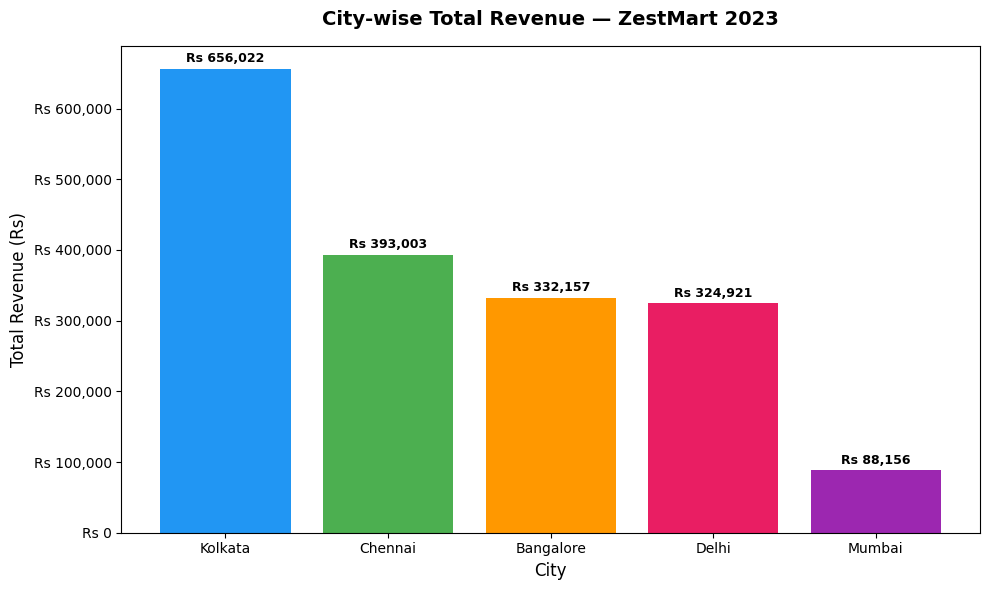

✅ Chart 1 saved!


In [44]:
# ── Chart 1: City-wise Revenue Bar Chart ─────────────────────

# Prepare data
city_rev = df.groupby("city")["net_amount"].sum().sort_values(ascending=False)

# Create figure
fig, ax = plt.subplots(figsize=(10, 6))

# Plot bars
bars = ax.bar(city_rev.index, city_rev.values,
              color=["#2196F3","#4CAF50","#FF9800","#E91E63","#9C27B0"])

# Add value labels on top of bars
for bar, val in zip(bars, city_rev.values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 5000,
            f"Rs {val:,.0f}",
            ha="center", va="bottom", fontsize=9, fontweight="bold")

# Labels & title
ax.set_title("City-wise Total Revenue — ZestMart 2023",
             fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("City", fontsize=12)
ax.set_ylabel("Total Revenue (Rs)", fontsize=12)
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"Rs {x:,.0f}"))

plt.tight_layout()
plt.savefig("chart1_city_revenue.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Chart 1 saved!")

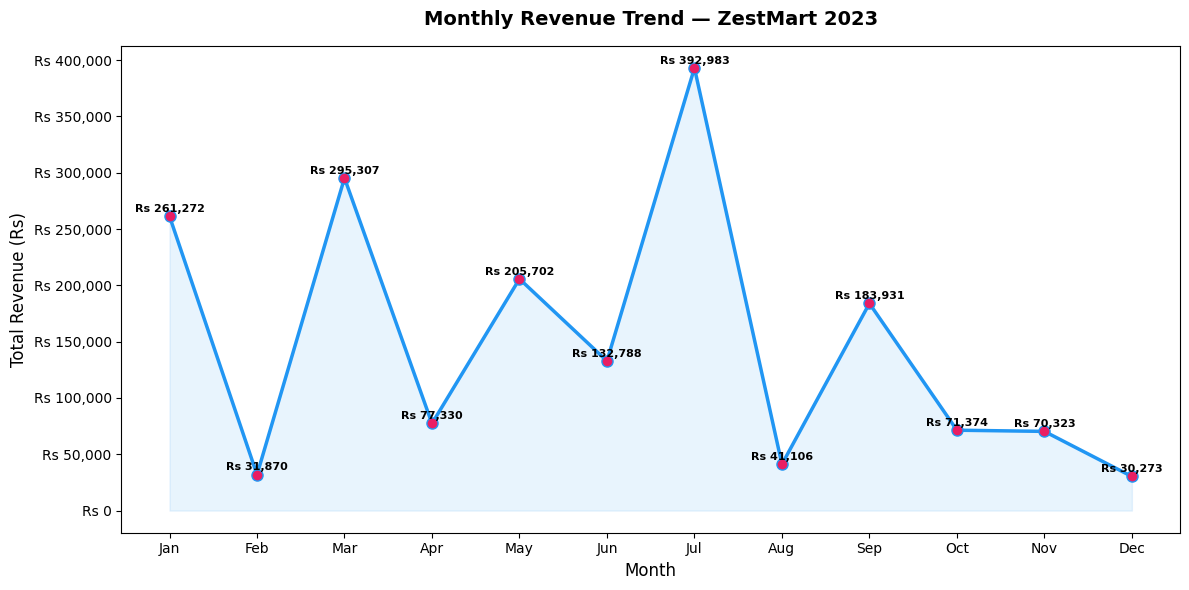

✅ Chart 2 saved!


In [45]:
# ── Chart 2: Monthly Revenue Trend Line Chart ────────────────

# Prepare data
monthly = df.groupby(["month","month_name"])["net_amount"].sum().reset_index()
monthly = monthly.sort_values("month")

# Create figure
fig, ax = plt.subplots(figsize=(12, 6))

# Plot line
ax.plot(monthly["month_name"], monthly["net_amount"],
        color="#2196F3", linewidth=2.5, marker="o",
        markersize=8, markerfacecolor="#E91E63")

# Add value labels on each point
for _, row in monthly.iterrows():
    ax.text(row["month_name"], row["net_amount"] + 2000,
            f"Rs {row['net_amount']:,.0f}",
            ha="center", va="bottom", fontsize=8, fontweight="bold")

# Fill area under line
ax.fill_between(monthly["month_name"], monthly["net_amount"],
                alpha=0.1, color="#2196F3")

# Labels & title
ax.set_title("Monthly Revenue Trend — ZestMart 2023",
             fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Month", fontsize=12)
ax.set_ylabel("Total Revenue (Rs)", fontsize=12)
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"Rs {x:,.0f}"))

plt.tight_layout()
plt.savefig("chart2_monthly_trend.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Chart 2 saved!")

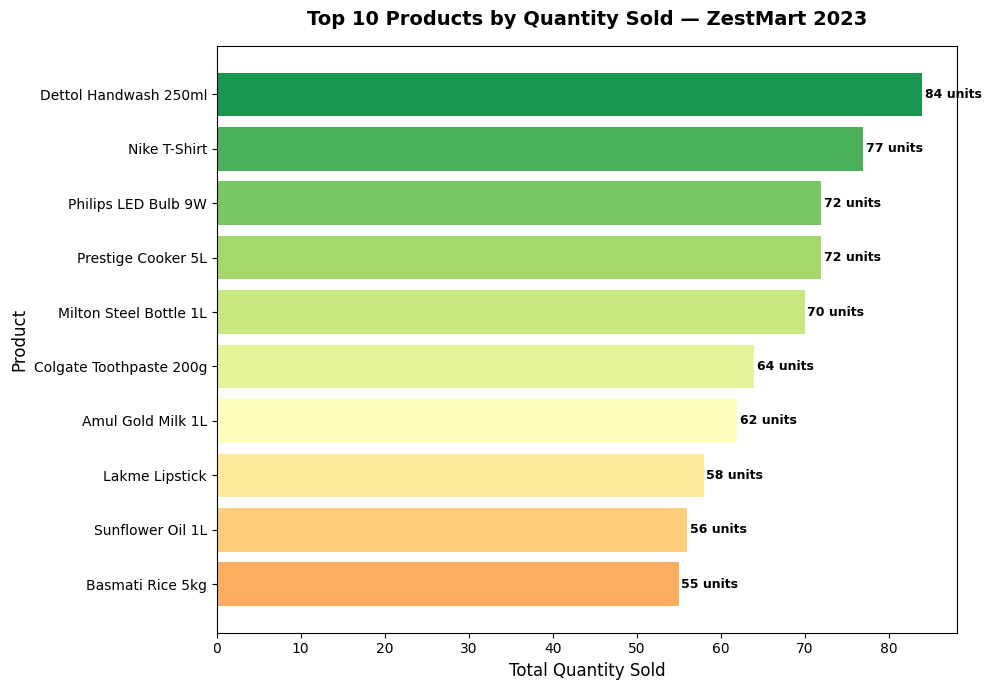

✅ Chart 3 saved!


In [46]:
# ── Chart 3: Top 10 Products Horizontal Bar Chart ────────────

# Prepare data
top_products = df.groupby("product_name")["quantity"].sum()\
                 .sort_values(ascending=True).tail(10)

# Create figure
fig, ax = plt.subplots(figsize=(10, 7))

# Plot horizontal bars
colors = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(top_products)))
bars = ax.barh(top_products.index, top_products.values, color=colors)

# Add value labels
for bar, val in zip(bars, top_products.values):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f"{val} units", va="center", fontsize=9, fontweight="bold")

# Labels & title
ax.set_title("Top 10 Products by Quantity Sold — ZestMart 2023",
             fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Total Quantity Sold", fontsize=12)
ax.set_ylabel("Product", fontsize=12)

plt.tight_layout()
plt.savefig("chart3_top_products.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Chart 3 saved!")

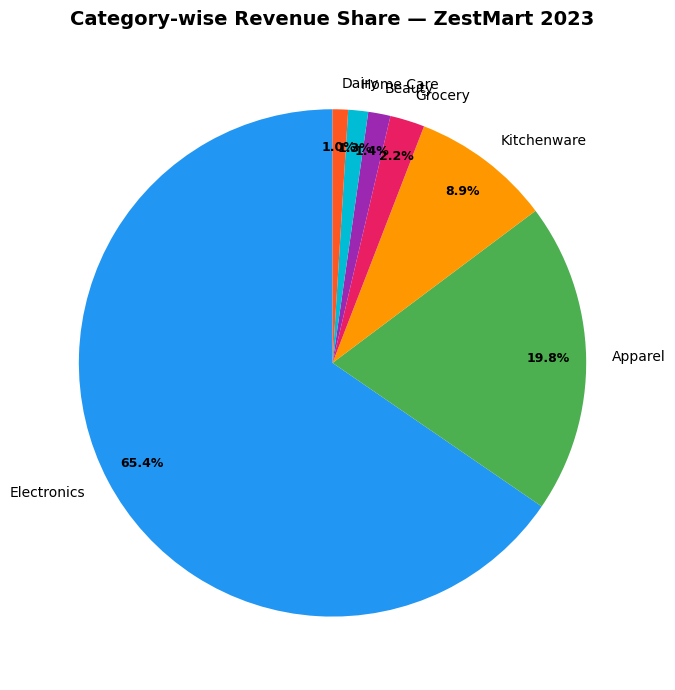

✅ Chart 4 saved!


In [47]:
# ── Chart 4: Category Revenue Pie Chart ──────────────────────

# Prepare data
cat_rev = df.groupby("category")["net_amount"].sum().sort_values(ascending=False)

# Create figure
fig, ax = plt.subplots(figsize=(10, 7))

# Colors
colors = ["#2196F3","#4CAF50","#FF9800","#E91E63",
          "#9C27B0","#00BCD4","#FF5722"]

# Plot pie
wedges, texts, autotexts = ax.pie(
    cat_rev.values,
    labels=cat_rev.index,
    autopct="%1.1f%%",
    colors=colors,
    startangle=90,
    pctdistance=0.85
)

# Style text
for text in autotexts:
    text.set_fontsize(9)
    text.set_fontweight("bold")

ax.set_title("Category-wise Revenue Share — ZestMart 2023",
             fontsize=14, fontweight="bold", pad=15)

plt.tight_layout()
plt.savefig("chart4_category_pie.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Chart 4 saved!")

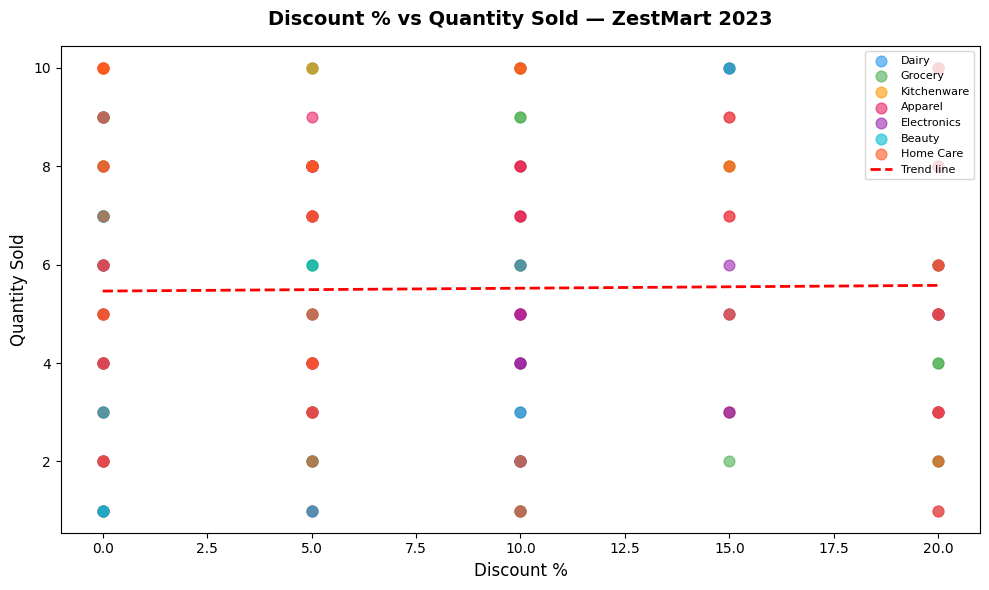

✅ Chart 5 saved!


In [48]:
# ── Chart 5: Discount vs Quantity Scatter Plot ────────────────

# Create figure
fig, ax = plt.subplots(figsize=(10, 6))

# Color by category
categories = df["category"].unique()
colors = ["#2196F3","#4CAF50","#FF9800","#E91E63",
          "#9C27B0","#00BCD4","#FF5722"]

for cat, color in zip(categories, colors):
    mask = df["category"] == cat
    ax.scatter(df[mask]["discount_pct"],
               df[mask]["quantity"],
               label=cat, color=color,
               alpha=0.6, s=60)

# Add trend line
z = np.polyfit(df["discount_pct"], df["quantity"], 1)
p = np.poly1d(z)
x_line = np.linspace(0, 20, 100)
ax.plot(x_line, p(x_line), "r--", linewidth=2, label="Trend line")

# Labels & title
ax.set_title("Discount % vs Quantity Sold — ZestMart 2023",
             fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Discount %", fontsize=12)
ax.set_ylabel("Quantity Sold", fontsize=12)
ax.legend(loc="upper right", fontsize=8)

plt.tight_layout()
plt.savefig("chart5_discount_scatter.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Chart 5 saved!")

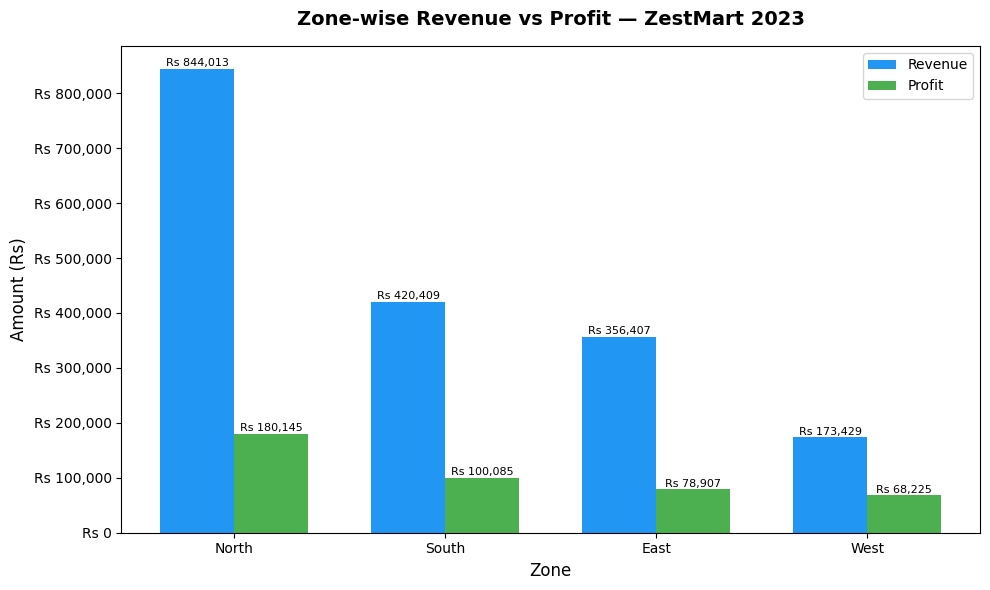

✅ Chart 6 saved!


In [49]:
# ── Chart 6: Zone-wise Performance Bar Chart ─────────────────

# Prepare data
zone_data = df.groupby("zone").agg(
    total_revenue=("net_amount", "sum"),
    total_profit=("profit", "sum")
).reset_index().sort_values("total_revenue", ascending=False)

# Create figure
fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(zone_data))
width = 0.35

# Plot grouped bars
bars1 = ax.bar(x - width/2, zone_data["total_revenue"],
               width, label="Revenue", color="#2196F3")
bars2 = ax.bar(x + width/2, zone_data["total_profit"],
               width, label="Profit", color="#4CAF50")

# Add value labels
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 1000,
            f"Rs {bar.get_height():,.0f}",
            ha="center", va="bottom", fontsize=8)

for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 1000,
            f"Rs {bar.get_height():,.0f}",
            ha="center", va="bottom", fontsize=8)

# Labels & title
ax.set_title("Zone-wise Revenue vs Profit — ZestMart 2023",
             fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Zone", fontsize=12)
ax.set_ylabel("Amount (Rs)", fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(zone_data["zone"])
ax.legend()
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"Rs {x:,.0f}"))

plt.tight_layout()
plt.savefig("chart6_zone_performance.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Chart 6 saved!")

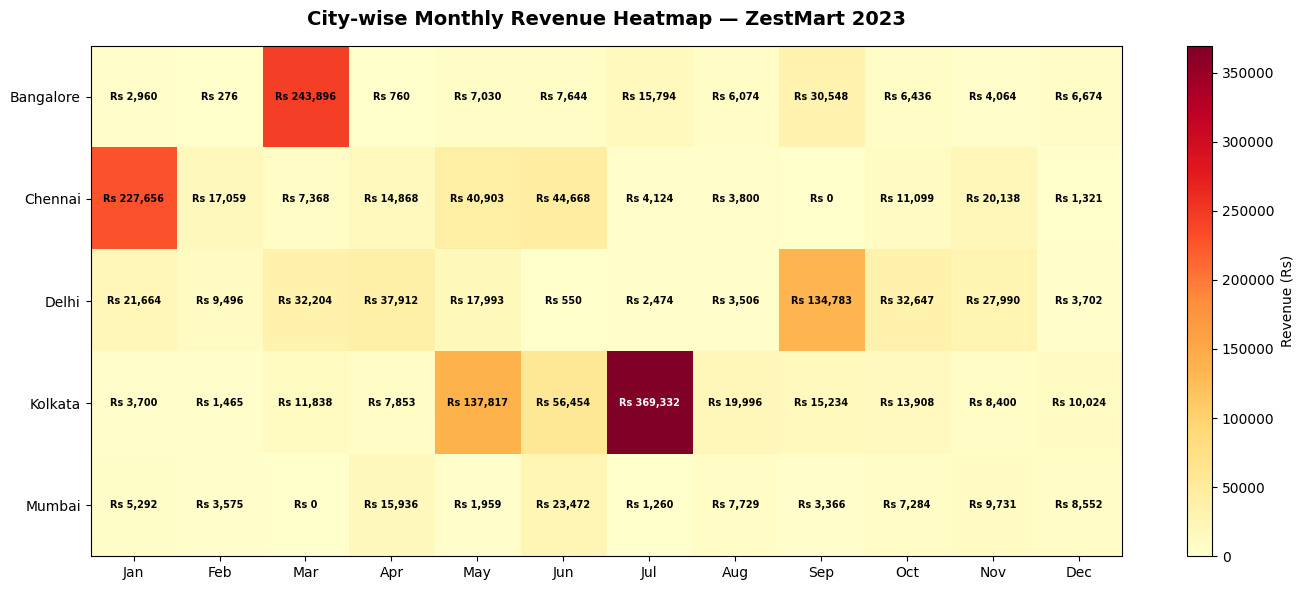

✅ Chart 7 saved!


In [50]:
# ── Chart 7: City vs Month Revenue Heatmap ───────────────────

# Prepare pivot data
pivot = df.pivot_table(
    index="city",
    columns="month_name",
    values="net_amount",
    aggfunc="sum",
    fill_value=0
)

# Reorder months
month_order = ["Jan","Feb","Mar","Apr","May","Jun",
               "Jul","Aug","Sep","Oct","Nov","Dec"]
pivot = pivot.reindex(columns=[m for m in month_order if m in pivot.columns])

# Create figure
fig, ax = plt.subplots(figsize=(14, 6))

# Plot heatmap using imshow
im = ax.imshow(pivot.values, cmap="YlOrRd", aspect="auto")

# Add colorbar
plt.colorbar(im, ax=ax, label="Revenue (Rs)")

# Add text annotations
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        val = pivot.values[i][j]
        ax.text(j, i, f"Rs {val:,.0f}",
                ha="center", va="center",
                fontsize=7, fontweight="bold",
                color="black" if val < pivot.values.max()*0.7 else "white")

# Labels & title
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)
ax.set_title("City-wise Monthly Revenue Heatmap — ZestMart 2023",
             fontsize=14, fontweight="bold", pad=15)

plt.tight_layout()
plt.savefig("chart7_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Chart 7 saved!")

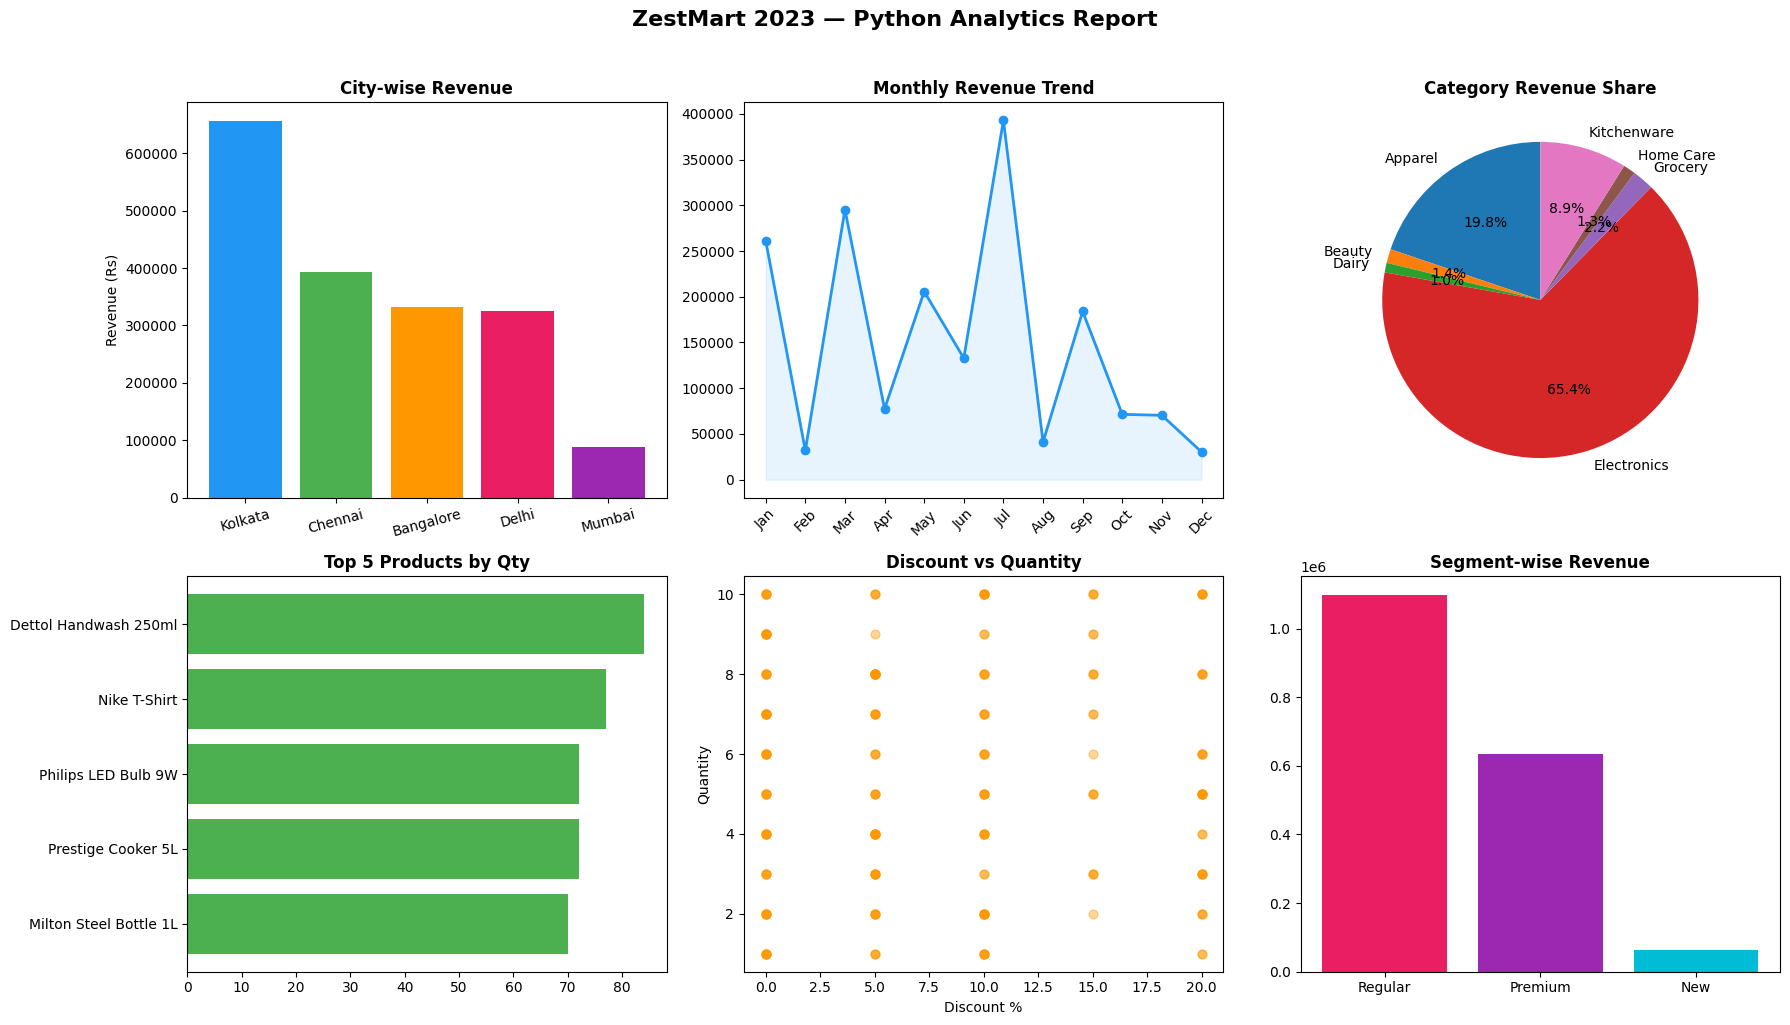

✅ Chart 8 — Combined Report saved!


In [51]:
# ── Chart 8: 6-Panel Combined Figure ─────────────────────────

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("ZestMart 2023 — Python Analytics Report",
             fontsize=16, fontweight="bold", y=1.02)

# Panel 1: City Revenue
city_rev = df.groupby("city")["net_amount"].sum().sort_values(ascending=False)
axes[0,0].bar(city_rev.index, city_rev.values,
              color=["#2196F3","#4CAF50","#FF9800","#E91E63","#9C27B0"])
axes[0,0].set_title("City-wise Revenue", fontweight="bold")
axes[0,0].set_ylabel("Revenue (Rs)")
axes[0,0].tick_params(axis="x", rotation=15)

# Panel 2: Monthly Trend
monthly = df.groupby(["month","month_name"])["net_amount"].sum().reset_index()
monthly = monthly.sort_values("month")
axes[0,1].plot(monthly["month_name"], monthly["net_amount"],
               color="#2196F3", marker="o", linewidth=2)
axes[0,1].fill_between(monthly["month_name"],
                        monthly["net_amount"], alpha=0.1, color="#2196F3")
axes[0,1].set_title("Monthly Revenue Trend", fontweight="bold")
axes[0,1].tick_params(axis="x", rotation=45)

# Panel 3: Category Pie
cat_rev = df.groupby("category")["net_amount"].sum()
axes[0,2].pie(cat_rev.values, labels=cat_rev.index,
              autopct="%1.1f%%", startangle=90)
axes[0,2].set_title("Category Revenue Share", fontweight="bold")

# Panel 4: Top 5 Products
top5 = df.groupby("product_name")["quantity"].sum()\
         .sort_values(ascending=True).tail(5)
axes[1,0].barh(top5.index, top5.values, color="#4CAF50")
axes[1,0].set_title("Top 5 Products by Qty", fontweight="bold")

# Panel 5: Scatter
axes[1,1].scatter(df["discount_pct"], df["quantity"],
                  alpha=0.4, color="#FF9800", s=40)
axes[1,1].set_title("Discount vs Quantity", fontweight="bold")
axes[1,1].set_xlabel("Discount %")
axes[1,1].set_ylabel("Quantity")

# Panel 6: Segment Revenue
seg_rev = df.groupby("segment")["net_amount"].sum().sort_values(ascending=False)
axes[1,2].bar(seg_rev.index, seg_rev.values,
              color=["#E91E63","#9C27B0","#00BCD4"])
axes[1,2].set_title("Segment-wise Revenue", fontweight="bold")

plt.tight_layout()
plt.savefig("chart8_combined_report.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Chart 8 — Combined Report saved!")

In [53]:
# ── Download All Charts ───────────────────────────────────────

from google.colab import files

charts = [
    "chart1_city_revenue.png",
    "chart2_monthly_trend.png",
    "chart3_top_products.png",
    "chart4_category_pie.png",
    "chart5_discount_scatter.png",
    "chart6_zone_performance.png",
    "chart7_heatmap.png",
    "chart8_combined_report.png"
]

for chart in charts:
    files.download(chart)
    print(f"✅ {chart} downloaded!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ chart1_city_revenue.png downloaded!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

✅ chart7_heatmap.png downloaded!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ chart8_combined_report.png downloaded!


In [54]:
# ── Import Libraries & Load Data ─────────────────────────────

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set seaborn style — automatically beautiful!
sns.set_theme(style="whitegrid", palette="muted")

# Display charts inline
%matplotlib inline

# Load cleaned data
df = pd.read_csv("zestmart_full.csv")
df["sale_date"] = pd.to_datetime(df["sale_date"])
df["month"]      = df["sale_date"].dt.month
df["month_name"] = df["sale_date"].dt.strftime("%b")

print("✅ Seaborn ready!")
print(f"✅ {df.shape[0]} rows loaded")

✅ Seaborn ready!
✅ 200 rows loaded


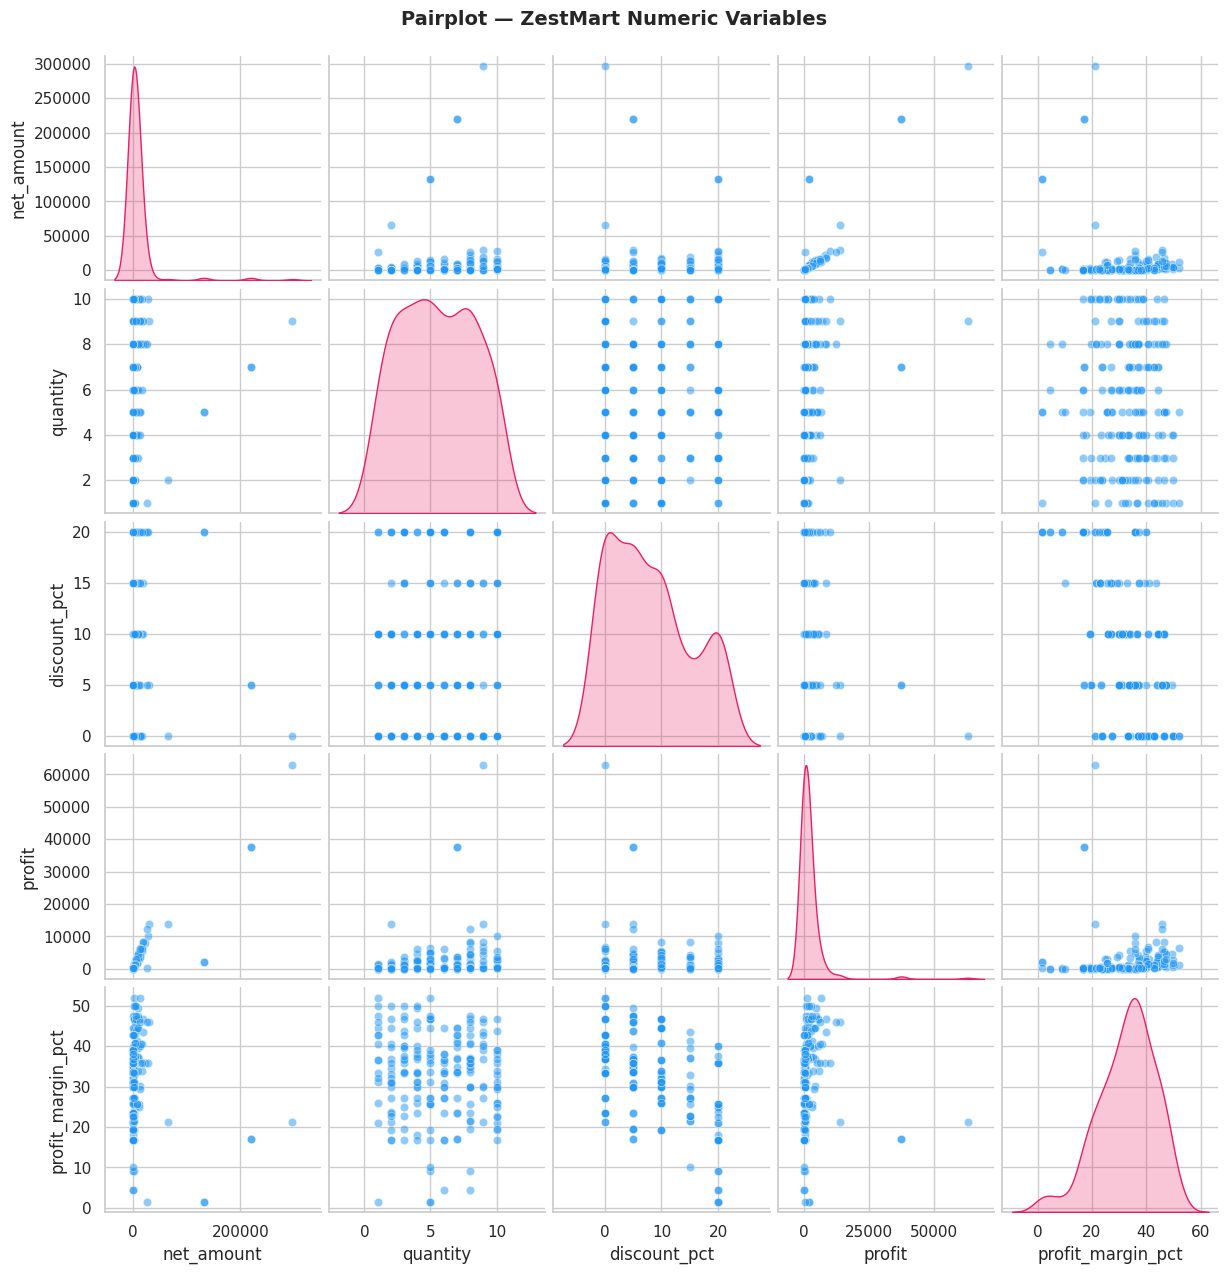

✅ Chart 1 — Pairplot saved!


In [55]:
# ── Chart 1: Pairplot ─────────────────────────────────────────

# Select numeric columns only
pair_data = df[["net_amount","quantity","discount_pct",
                "profit","profit_margin_pct"]].copy()

# Plot pairplot
fig = sns.pairplot(pair_data, diag_kind="kde",
                   plot_kws={"alpha":0.5, "color":"#2196F3"},
                   diag_kws={"color":"#E91E63"})

fig.fig.suptitle("Pairplot — ZestMart Numeric Variables",
                 fontsize=14, fontweight="bold", y=1.02)

plt.savefig("sns_chart1_pairplot.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Chart 1 — Pairplot saved!")

/tmp/ipykernel_1106/2018450174.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="category", y="net_amount",


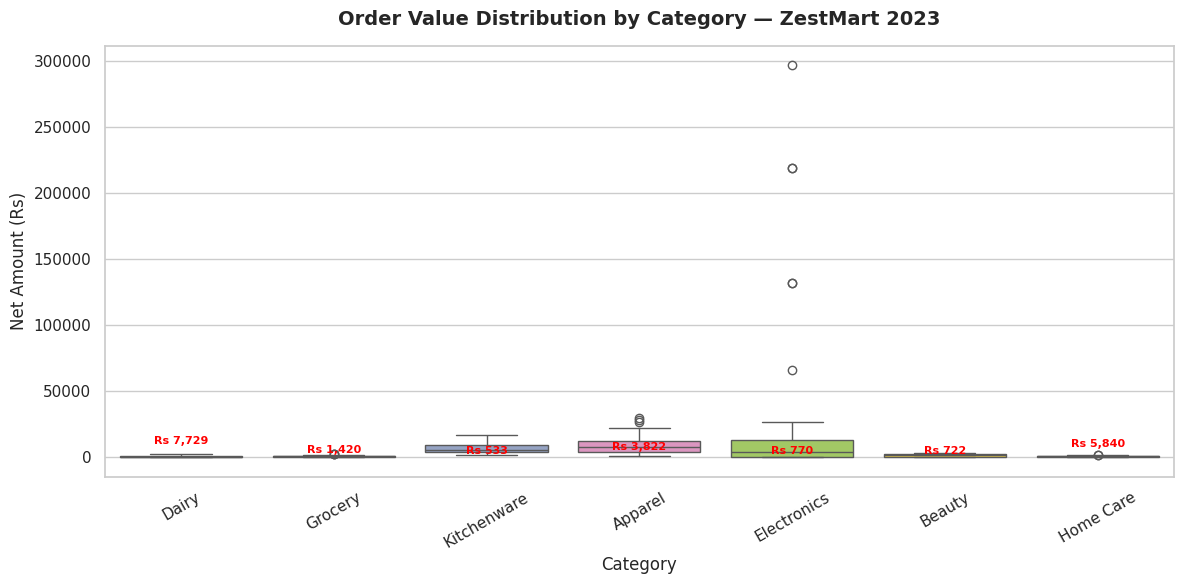

✅ Chart 2 — Boxplot saved!


In [56]:
# ── Chart 2: Boxplot — Returns by Category ───────────────────

fig, ax = plt.subplots(figsize=(12, 6))

sns.boxplot(data=df, x="category", y="net_amount",
            palette="Set2", ax=ax)

ax.set_title("Order Value Distribution by Category — ZestMart 2023",
             fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Category", fontsize=12)
ax.set_ylabel("Net Amount (Rs)", fontsize=12)
ax.tick_params(axis="x", rotation=30)

# Add median annotations
medians = df.groupby("category")["net_amount"].median()
for i, (cat, med) in enumerate(medians.items()):
    ax.text(i, med + 500, f"Rs {med:,.0f}",
            ha="center", va="bottom",
            fontsize=8, fontweight="bold", color="red")

plt.tight_layout()
plt.savefig("sns_chart2_boxplot.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Chart 2 — Boxplot saved!")

/tmp/ipykernel_1106/918926590.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x="city", y="net_amount",


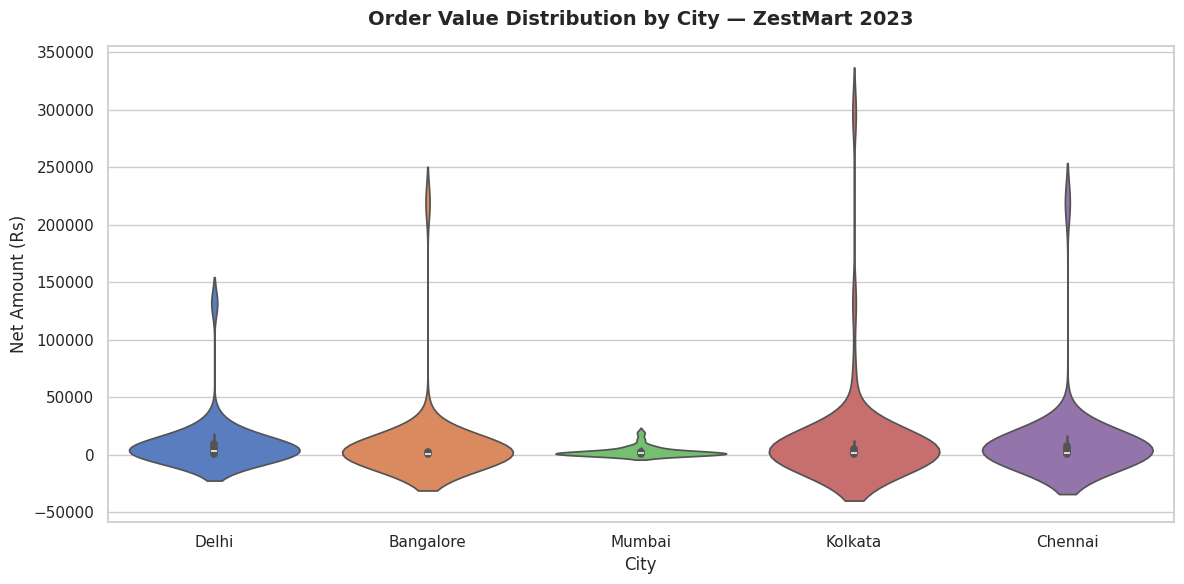

✅ Chart 3 — Violin Plot saved!


In [57]:
# ── Chart 3: Violin Plot — Order Value by City ───────────────

fig, ax = plt.subplots(figsize=(12, 6))

sns.violinplot(data=df, x="city", y="net_amount",
               palette="muted", inner="box", ax=ax)

ax.set_title("Order Value Distribution by City — ZestMart 2023",
             fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("City", fontsize=12)
ax.set_ylabel("Net Amount (Rs)", fontsize=12)

plt.tight_layout()
plt.savefig("sns_chart3_violin.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Chart 3 — Violin Plot saved!")

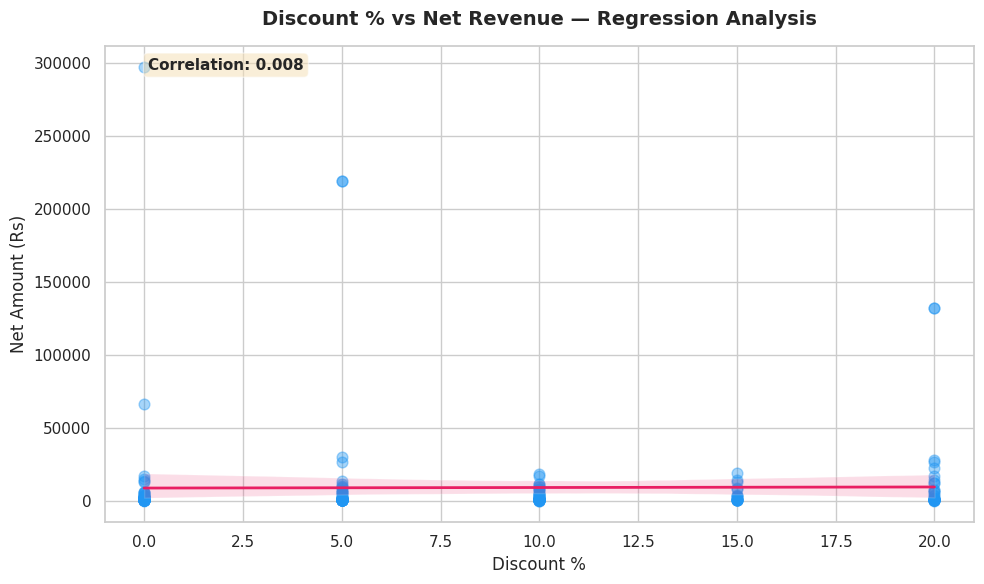

✅ Chart 4 — Regression Plot saved!


In [58]:
# ── Chart 4: Regression Plot — Discount vs Revenue ───────────

fig, ax = plt.subplots(figsize=(10, 6))

sns.regplot(data=df, x="discount_pct", y="net_amount",
            scatter_kws={"alpha":0.4, "color":"#2196F3", "s":60},
            line_kws={"color":"#E91E63", "linewidth":2},
            ax=ax)

ax.set_title("Discount % vs Net Revenue — Regression Analysis",
             fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Discount %", fontsize=12)
ax.set_ylabel("Net Amount (Rs)", fontsize=12)

# Add correlation annotation
corr = df["discount_pct"].corr(df["net_amount"])
ax.text(0.05, 0.95, f"Correlation: {corr:.3f}",
        transform=ax.transAxes,
        fontsize=11, fontweight="bold",
        bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5))

plt.tight_layout()
plt.savefig("sns_chart4_regression.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Chart 4 — Regression Plot saved!")

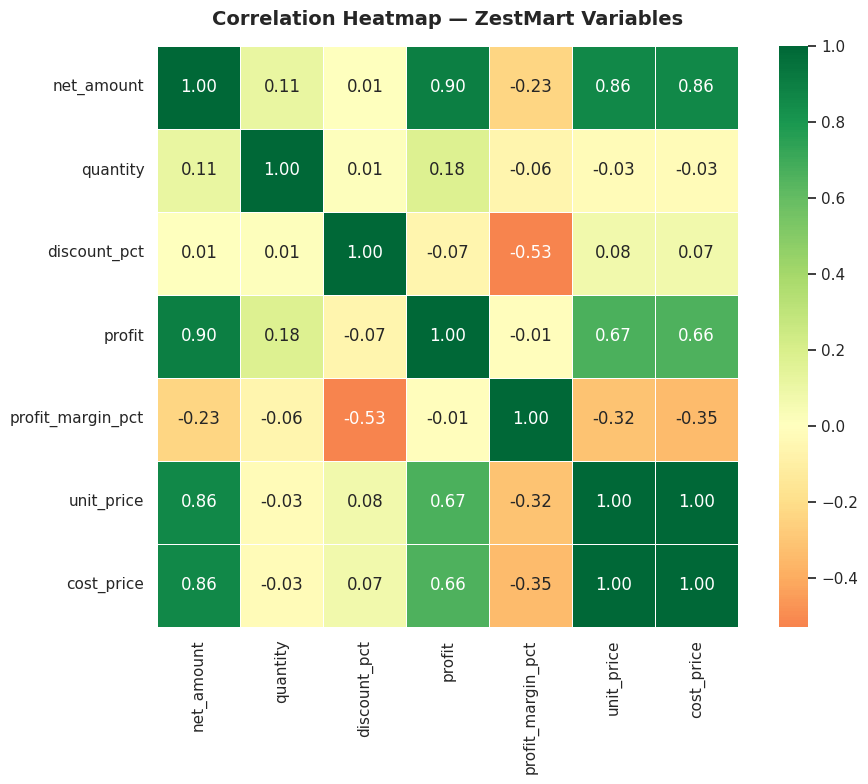

✅ Chart 5 — Correlation Heatmap saved!


In [59]:
# ── Chart 5: Correlation Heatmap ─────────────────────────────

# Select numeric columns
numeric_cols = ["net_amount","quantity","discount_pct",
                "profit","profit_margin_pct","unit_price","cost_price"]
corr_matrix = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(corr_matrix,
            annot=True, fmt=".2f",
            cmap="RdYlGn",
            center=0,
            square=True,
            linewidths=0.5,
            ax=ax)

ax.set_title("Correlation Heatmap — ZestMart Variables",
             fontsize=14, fontweight="bold", pad=15)

plt.tight_layout()
plt.savefig("sns_chart5_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Chart 5 — Correlation Heatmap saved!")

/tmp/ipykernel_1106/3020975841.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="segment",


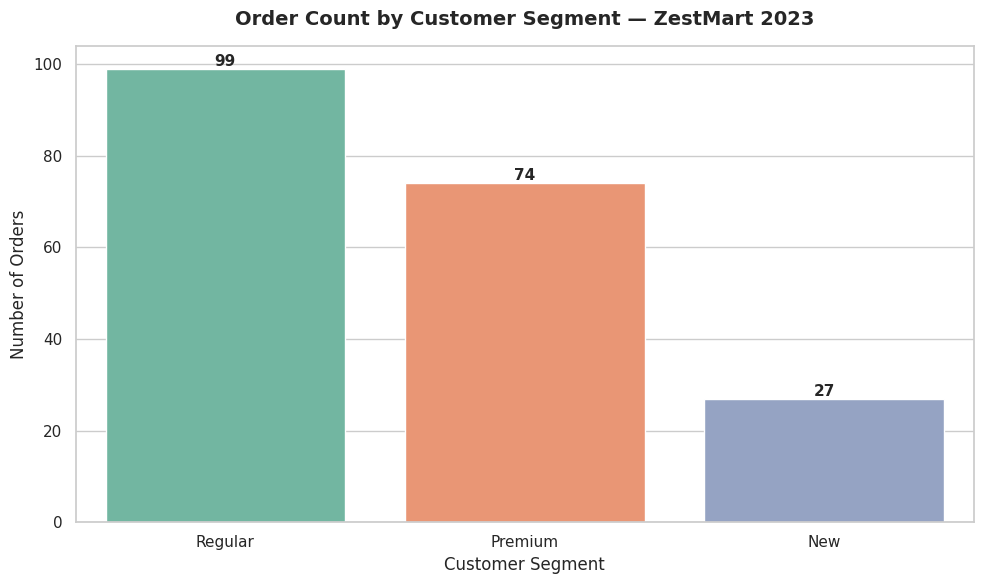

✅ Chart 6 — Countplot saved!


In [60]:
# ── Chart 6: Countplot — Segment Distribution ────────────────

fig, ax = plt.subplots(figsize=(10, 6))

sns.countplot(data=df, x="segment",
              order=df["segment"].value_counts().index,
              palette="Set2", ax=ax)

# Add count labels
for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}",
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha="center", va="bottom",
                fontsize=11, fontweight="bold")

ax.set_title("Order Count by Customer Segment — ZestMart 2023",
             fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Customer Segment", fontsize=12)
ax.set_ylabel("Number of Orders", fontsize=12)

plt.tight_layout()
plt.savefig("sns_chart6_countplot.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Chart 6 — Countplot saved!")

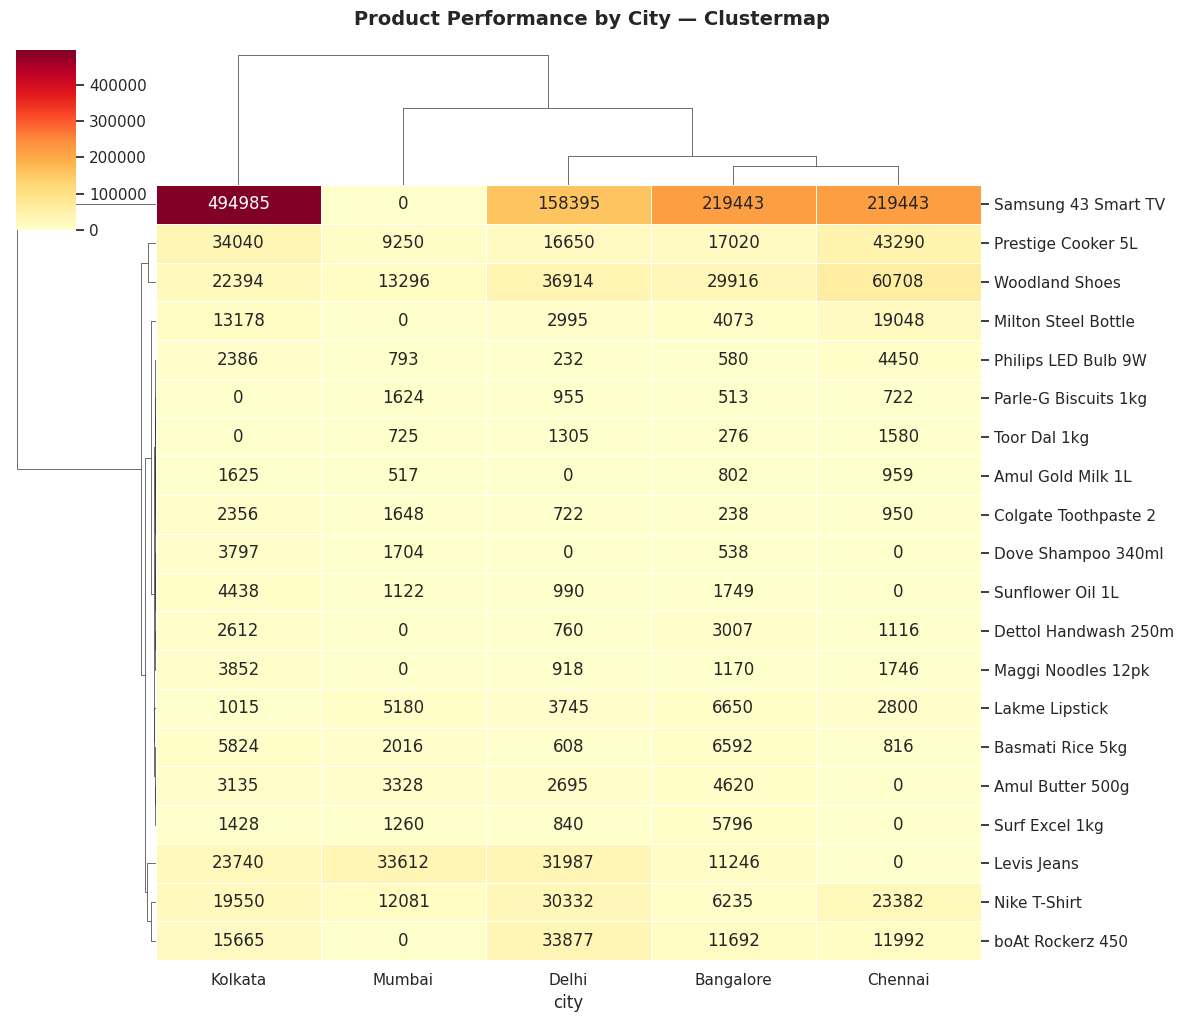

✅ Chart 7 — Clustermap saved!


In [61]:
# ── Chart 7: Clustermap — Product Performance ────────────────

# Prepare pivot data
product_pivot = df.pivot_table(
    index="product_name",
    columns="city",
    values="net_amount",
    aggfunc="sum",
    fill_value=0
)

# Shorten product names
product_pivot.index = [name[:20] for name in product_pivot.index]

fig = sns.clustermap(product_pivot,
                     cmap="YlOrRd",
                     figsize=(12, 10),
                     annot=True, fmt=".0f",
                     linewidths=0.5,
                     dendrogram_ratio=0.15)

fig.fig.suptitle("Product Performance by City — Clustermap",
                 fontsize=14, fontweight="bold", y=1.02)

plt.savefig("sns_chart7_clustermap.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Chart 7 — Clustermap saved!")

/tmp/ipykernel_1106/2332993056.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="category", y="net_amount",
/tmp/ipykernel_1106/2332993056.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x="city", y="net_amount",
/tmp/ipykernel_1106/2332993056.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="segment",
/tmp/ipykernel_1106/2332993056.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=Fal

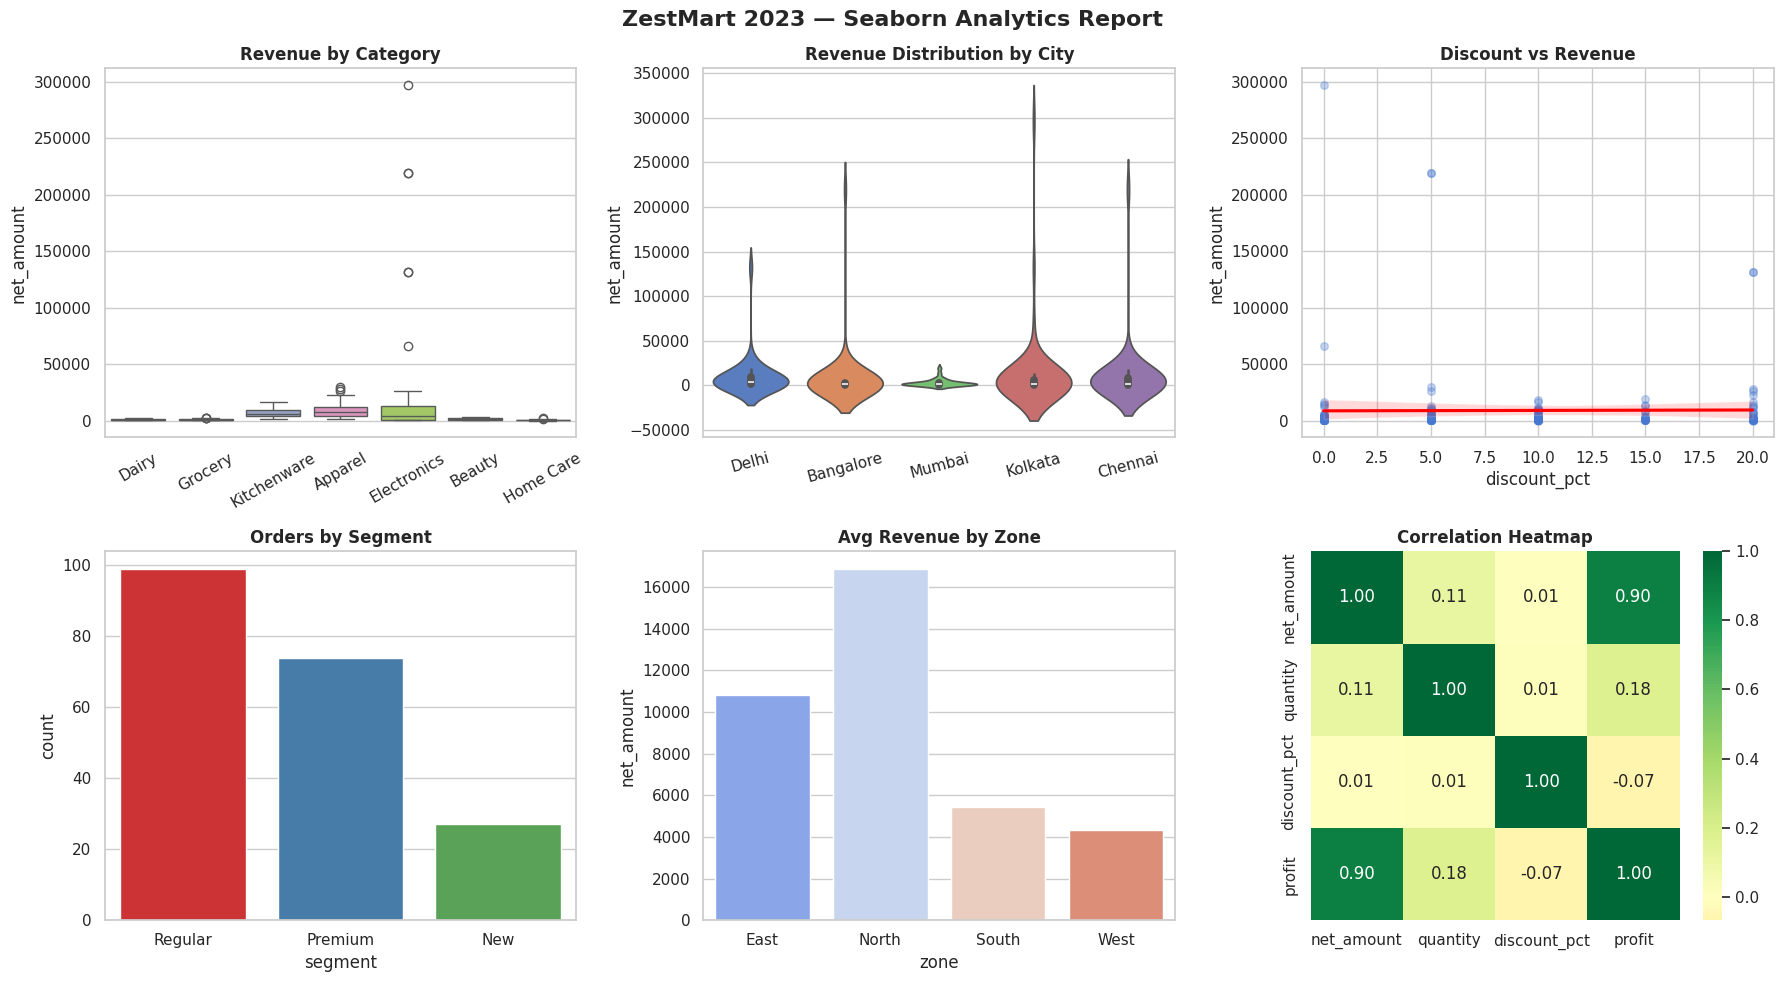

✅ Chart 8 — Combined Seaborn Report saved!


In [62]:
# ── Chart 8: 6-Panel Seaborn Report ──────────────────────────

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("ZestMart 2023 — Seaborn Analytics Report",
             fontsize=16, fontweight="bold")

# Panel 1: Boxplot — revenue by category
sns.boxplot(data=df, x="category", y="net_amount",
            palette="Set2", ax=axes[0,0])
axes[0,0].set_title("Revenue by Category", fontweight="bold")
axes[0,0].tick_params(axis="x", rotation=30)
axes[0,0].set_xlabel("")

# Panel 2: Violin — revenue by city
sns.violinplot(data=df, x="city", y="net_amount",
               palette="muted", inner="box", ax=axes[0,1])
axes[0,1].set_title("Revenue Distribution by City", fontweight="bold")
axes[0,1].tick_params(axis="x", rotation=15)
axes[0,1].set_xlabel("")

# Panel 3: Regression — discount vs revenue
sns.regplot(data=df, x="discount_pct", y="net_amount",
            scatter_kws={"alpha":0.3, "s":30},
            line_kws={"color":"red"},
            ax=axes[0,2])
axes[0,2].set_title("Discount vs Revenue", fontweight="bold")

# Panel 4: Countplot — segment
sns.countplot(data=df, x="segment",
              order=df["segment"].value_counts().index,
              palette="Set1", ax=axes[1,0])
axes[1,0].set_title("Orders by Segment", fontweight="bold")

# Panel 5: Barplot — zone revenue
zone_data = df.groupby("zone")["net_amount"].mean().reset_index()
sns.barplot(data=zone_data, x="zone", y="net_amount",
            palette="coolwarm", ax=axes[1,1])
axes[1,1].set_title("Avg Revenue by Zone", fontweight="bold")

# Panel 6: Heatmap — mini correlation
mini_corr = df[["net_amount","quantity",
                "discount_pct","profit"]].corr()
sns.heatmap(mini_corr, annot=True, fmt=".2f",
            cmap="RdYlGn", center=0,
            ax=axes[1,2], square=True)
axes[1,2].set_title("Correlation Heatmap", fontweight="bold")

plt.tight_layout()
plt.savefig("sns_chart8_combined.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Chart 8 — Combined Seaborn Report saved!")

In [63]:
# ── Download All Charts ───────────────────────────────────────

from google.colab import files

charts = [
    "sns_chart1_pairplot.png",
    "sns_chart2_boxplot.png",
    "sns_chart3_violin.png",
    "sns_chart4_regression.png",
    "sns_chart5_heatmap.png",
    "sns_chart6_countplot.png",
    "sns_chart7_clustermap.png",
    "sns_chart8_combined.png"
]

for chart in charts:
    files.download(chart)
    print(f"✅ {chart} downloaded!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ sns_chart1_pairplot.png downloaded!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

✅ sns_chart7_clustermap.png downloaded!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ sns_chart8_combined.png downloaded!
